#**QR-code ссылка на репозиторий в [Github](https://github.com/kubenet/ML_course)**

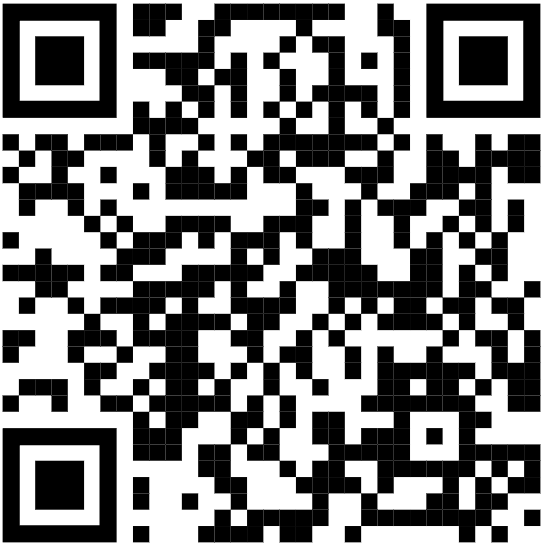

# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

---

# Практика №4: Регуляризация, Переобучение и Отбор Признаков

## 🎯 Цели занятия
1.  Изучить эффект переобучения на примере полиномиальной регрессии.
2.  Понять разницу между $L_1$ (Lasso) и $L_2$ (Ridge) регуляризацией.
3.  Научиться подбирать гиперпараметры через кросс-валидацию.
4.  Проанализировать устойчивость отбора признаков на реальных данных.

---

## 📚 Теоретический блок 1:Bias-Variance Tradeoff и Полиномиальная регрессия

**Концепция:**
Модель машинного обучения стремится минимизировать ошибку обобщения. Она складывается из:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **Низкая степень полинома:** Высокое смещение (Bias), модель слишком простая (недообучение).
*   **Высокая степень полинома:** Высокая дисперсия (Variance), модель подстраивается под шум (переобучение).

**Регуляризация:**
Чтобы контролировать сложность модели, мы добавляем штрафной член к функции потерь (Loss Function):
*   **Ridge ($L_2$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} \theta_j^2$. Сжимает веса, но не обнуляет их.
*   **Lasso ($L_1$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} |\theta_j|$. Может обнулять веса, выполняя отбор признаков.

> ⚠️ **Важно:** Перед применением Ridge и Lasso данные необходимо масштабировать (Standardization), иначе штраф будет применяться неравномерно к признакам с разными масштабами.




















---

## 💻 Практический блок 1: Генерация данных и Кривые обучения






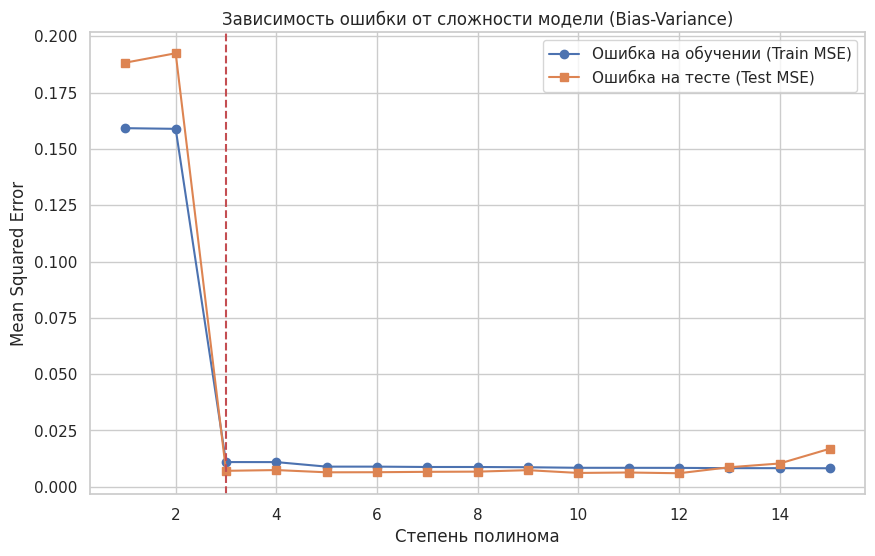

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Генерация синтетических данных
np.random.seed(42)
n_samples = 100
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
# Истинная зависимость: синусоида + шум
y_syn = np.sin(X_syn.ravel()) + np.random.normal(0, 0.1, n_samples)

# Разделение на train и test
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)
# Разделение данных на обучающую (70%) и тестовую (30%) выборки. Тестовая выборка имитирует новые, невиданные данные для оценки обобщающей способности модели.

# 2. Построение кривых обучения для степеней 1-15
degrees = range(1, 16)
train_errors, test_errors = [], []


# Для каждой степени полинома (от 1 до 15):
# Создаются полиномиальные признаки
# Данные масштабируются (критично для сравнения с Ridge/Lasso)
# Обучается линейная регрессия
# Вычисляется MSE на train и test
for d in degrees:
    # Пайплайн: Полином -> Масштабирование -> Линейная регрессия
    # Примечание: Для обычной регрессии масштабирование полиномов не всегда критично,
    # но для сравнения с Ridge/Lasso введем его сразу для единообразия.
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Ошибка на обучении (Train MSE)', marker='o')
plt.plot(degrees, test_errors, label='Ошибка на тесте (Test MSE)', marker='s')
plt.xlabel('Степень полинома')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от сложности модели (Bias-Variance)')
plt.legend()
plt.axvline(x=3, color='r', linestyle='--', label='Примерная оптимальная сложность')
plt.show()

###График: Ошибка на обучении vs Ошибка на тесте

###Визуальная интерпретация:
- Синяя линия (Train): Монотонно убывает, стремится к нулю
- Оранжевая линия (Test): U-образная кривая с минимумом при степени 3-5
- Разрыв (Gap): Чем больше разрыв между линиями, тем сильнее переобучение

###Как мы это используем
- Выбор оптимальной сложности модели: Находим степень полинома, где ошибка на тесте минимальна.
- Диагностика переобучения: Если Train MSE << Test MSE → модель запоминает шум.
- Обоснование регуляризации: Показываем, что простое увеличение сложности ухудшает обобщение.

"Эксперимент демонстрирует классический `Bias-Variance Tradeoff`: увеличение сложности модели снижает смещение, но увеличивает дисперсию, что приводит к росту ошибки обобщения после определённого порога."

### 🧠 Комментарий:
Обратите внимание на график. Ошибка на обучении монотонно убывает (модель запоминает данные). Ошибка на тесте сначала падает, а затем растет после определенной степени (обычно 3-5 для синуса). Это точка **переобучения**.

##Выводы:

- Сложность ≠ Качество - модель 15-й степени хуже модели 4-й степени на новых данных
- Нужен баланс - оптимальная степень полинома соответствует минимуму Test MSE
- Train MSE ненадёжен - нельзя оценивать модель только по ошибке на обучении
- Регуляризация необходима - для высоких степеней нужен механизм контроля сложности

---

## 📚 Теоретический блок 2: Влияние параметра $\alpha$ на коэффициенты

При увеличении $\alpha$ (силы регуляризации):
1.  **Ridge:** Коэффициенты стремятся к нулю асимптотически.
2.  **Lasso:** Коэффициенты становятся равными нулю точно (спарсность). Это позволяет исключить неинформативные признаки.

---

## 💻 Практический блок 2: Пути регуляризации (Coefficient Paths)

Для демонстрации возьмем высокую степень полинома (например, 15), чтобы создать много признаков и увидеть, как регуляризация их "гасит".


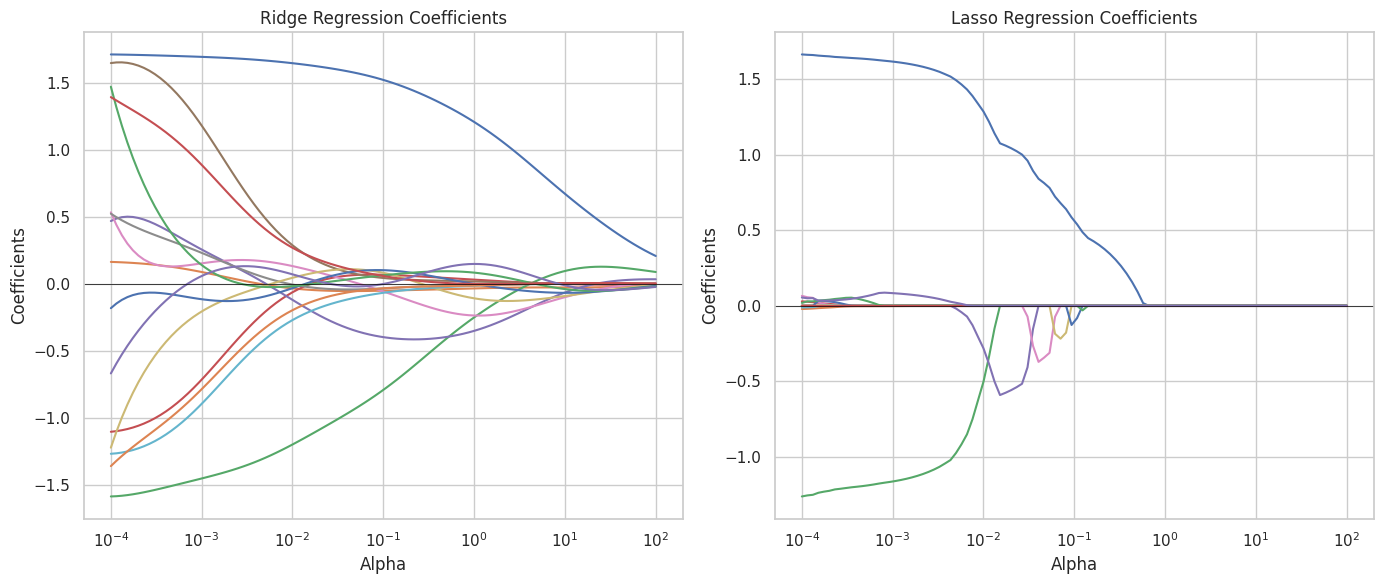

In [ ]:
# Создаем полиномиальные признаки высокой степени
poly = PolynomialFeatures(degree=15, include_bias=False)
# Получаем 15 признаков из 1 исходного: x, x², x³, ..., x¹⁵

X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

# Масштабируем признаки (Критично для регуляризации!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

"""
Почему масштабирование обязательно:
- Ridge/Lasso штрафуют величину коэффициентов
- Без масштабирования признак с большим диапазоном значений получит меньший коэффициент и меньший штраф
- Это приведёт к несправедливой регуляризации
"""

# Диапазон альфа (логарифмическая шкала)
alphas = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

# Визуализация путей коэффициентов
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Ridge
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Regression Coefficients')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')
ax[0].axhline(0, color='black', linewidth=0.5)

# Lasso
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Regression Coefficients')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Coefficients')
ax[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Показать, как меняются 15 коэффициентов модели при увеличении штрафа α.

### 📊 Какие результаты мы видим

- Два графика: Ridge Coefficients и Lasso Coefficients
- Ось X: Alpha (логарифмическая шкала)
- Ось Y: Значения коэффициентов

### Визуальная интерпретация:
- Ridge: Все 15 линий плавно сходятся к нулю, но никогда не достигают его
- Lasso: Линии "падают" на ноль и остаются там (вертикальный излом)

### 🧠 Комментарий:
На графике Lasso вы увидите, что линии "падают" на ноль и остаются там. Это свойство $L_1$-нормы. В Ridge линии просто приближаются к нулю. Это делает Lasso мощным инструментом для интерпретации моделей.

##Выводы
 "Различие обусловлено геометрией штрафных функций:
- L1-норма имеет 'углы' в точках обнуления, что позволяет решению достигать нуля точно.
- L2-норма имеет гладкую сферическую форму, поэтому коэффициенты лишь асимптотически приближаются к нулю."

---

## 💻 Практический блок 3: Автоматический подбор (GridSearchCV)

Вместо ручного перебора используем кросс-валидацию.

In [ ]:
# Настройка пайплайна для подбора
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge()) # Будем менять и модель, и альфа в сетке
])

# Параметрическая сетка
param_grid = {
    'reg': [Ridge(), Lasso(max_iter=10000)],
    'reg__alpha': np.logspace(-4, 2, 20)
}

# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_syn, y_train_syn)

print(f"Лучший счет (MSE): {-grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

# Сравнение лучшей модели с базовой
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_syn)
print(f"Test MSE Best Model: {mean_squared_error(y_test_syn, y_pred_best):.4f}")

Лучший счет (MSE): 0.0105
Лучшие параметры: {'reg': Ridge(), 'reg__alpha': np.float64(0.0001)}
Test MSE Best Model: 0.0064


---

## 📚 Теоретический блок 3: Реальные данные и Мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда признаки сильно коррелируют друг с другом.
*   **Проблема:** В обычной линейной регрессии (OLS) это приводит к огромным дисперсиям оценок коэффициентов (модель становится неустойчивой).
*   **Решение:** Ridge-регуляризация стабилизирует решение, жертвуя небольшой несмещенностью ради снижения дисперсии.

---

## 💻 Практический блок 4: Анализ на датасете Diabetes


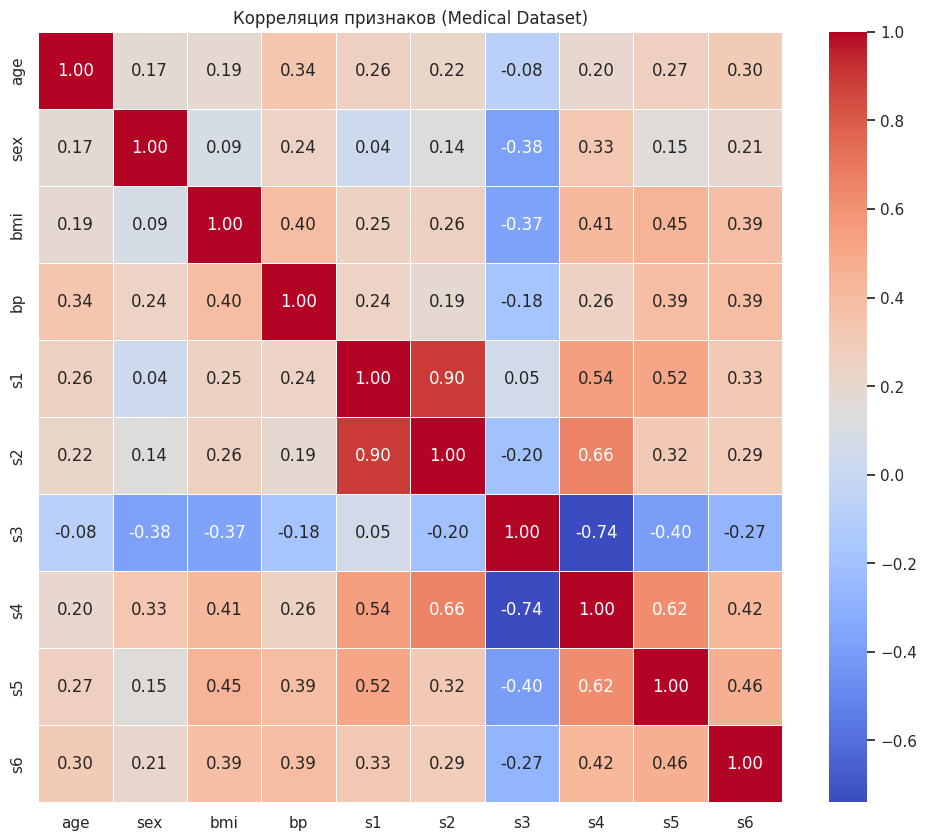

    Model        R²          MSE  Non-Zero Coefs
0  Linear  0.517748  2859.696348              10
1   Ridge  0.517582  2860.682243              10
2   Lasso  0.517376  2861.903917               9

Лучшая модель по R²: Linear


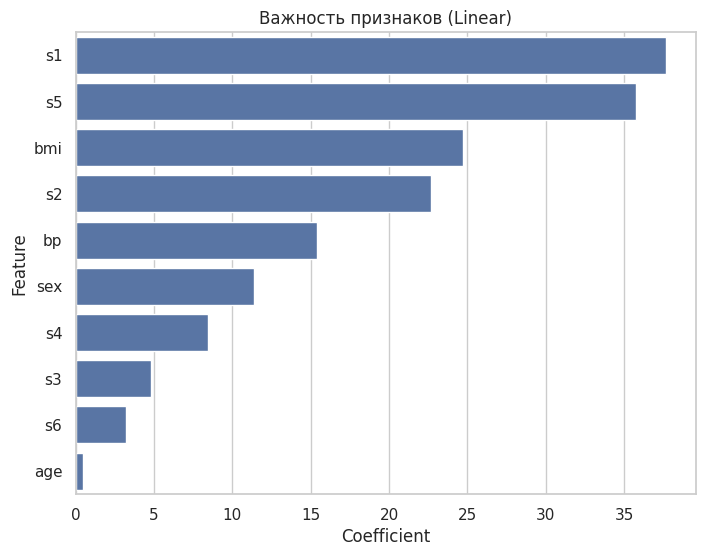

In [ ]:
# Загрузка медицинских данных
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

# 1. Тепловая карта корреляций
plt.figure(figsize=(12, 10))
corr_matrix = X_real.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляция признаков (Medical Dataset)')
plt.show()

# 2. Сравнение моделей
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000)
}

results = []

for name, model in models.items():
    # Пайплайн с масштабированием
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_real, y_real)

    y_pred = pipe.predict(X_real)
    r2 = r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)

    # Получаем коэффициенты
    coefs = pipe.named_steps['reg'].coef_
    non_zero = np.sum(coefs != 0)

    results.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'Non-Zero Coefs': non_zero
    })

results_df = pd.DataFrame(results)
print(results_df)

# 3. Анализ важности признаков для лучшей модели (по R²)
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")

# Визуализация коэффициентов лучшей модели
best_pipe = Pipeline([('scaler', StandardScaler()), ('reg', models[best_model_name])])
best_pipe.fit(X_real, y_real)
coefs = best_pipe.named_steps['reg'].coef_

feat_importance = pd.DataFrame({
    'Feature': X_real.columns,
    'Coefficient': np.abs(coefs)
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=feat_importance)
plt.title(f'Важность признаков ({best_model_name})')
plt.show()

---

## 💻 Практический блок 5: Устойчивость отбора признаков (Stability Check)

Lasso может быть чувствителен к шуму в данных. Проверим, какие признаки отбираются стабильно.


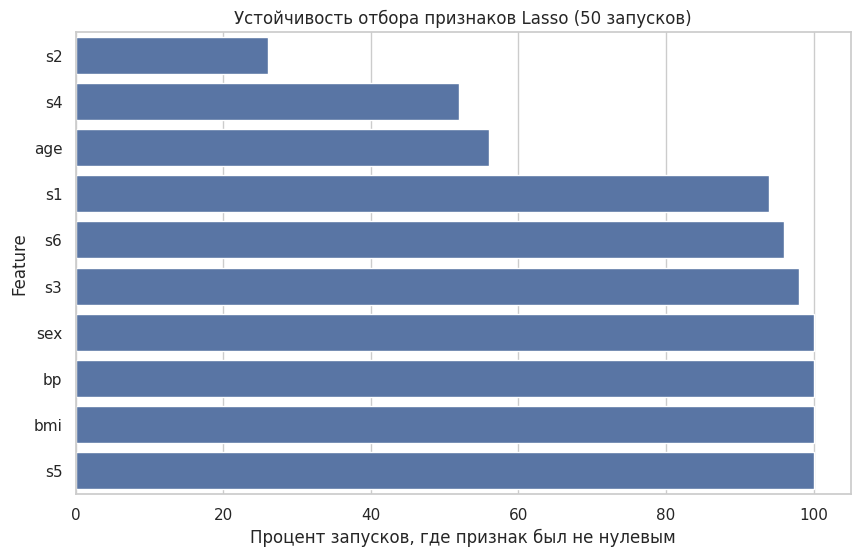

Признаки, отобранные более чем в 80% случаев (Стабильные):
['sex' 'bmi' 'bp' 's1' 's3' 's5' 's6']


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV

n_runs = 50
selected_features_count = {col: 0 for col in X_real.columns}

for i in range(n_runs):
    # Разные разбиения данных
    X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=i)

    # Подбор альфа через кросс-валидацию внутри цикла для честности
    lasso_cv = LassoCV(cv=5, random_state=i, max_iter=10000)
    pipe_stab = Pipeline([('scaler', StandardScaler()), ('reg', lasso_cv)])
    pipe_stab.fit(X_tr, y_tr)

    coefs = pipe_stab.named_steps['reg'].coef_

    for j, col in enumerate(X_real.columns):
        if coefs[j] != 0:
            selected_features_count[col] += 1

# Визуализация стабильности
stability_df = pd.DataFrame(list(selected_features_count.items()), columns=['Feature', 'Selection_Frequency'])
stability_df['Frequency_%'] = (stability_df['Selection_Frequency'] / n_runs) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency_%', y='Feature', data=stability_df.sort_values('Frequency_%'))
plt.title(f'Устойчивость отбора признаков Lasso ({n_runs} запусков)')
plt.xlabel('Процент запусков, где признак был не нулевым')
plt.show()

print("Признаки, отобранные более чем в 80% случаев (Стабильные):")
print(stability_df[stability_df['Frequency_%'] > 80]['Feature'].values)

---

## 📝 Выводы и Рекомендации

На основе проведенного эксперимента можно сформулировать следующие рекомендации:

| Цель задачи | Рекомендуемая модель | Обоснование |
| :--- | :--- | :--- |
| **Максимальная точность** | **Ridge** или **ElasticNet** | Ridge лучше справляется с мультиколлинеарностью, не отбрасывая информацию. |
| **Интерпретируемость** | **Lasso** | Позволяет получить разреженную модель (мало признаков), легче объяснить бизнесу. |
| **Много шума / признаков** | **Lasso** | Выполняет автоматический отбор признаков (Feature Selection). |
| **Сильная корреляция признаков** | **Ridge** | Lasso может случайно выбрать один из коррелирующих признаков, Ridge распределит вес между ними. |

---

## 🎓 Задания для самостоятельного решения

Попробуйте выполнить следующие задания, чтобы закрепить материал. Не забудьте документировать свои выводы в ячейках Markdown.

### Задание 1: Сравнение ElasticNet
Реализуйте модель **ElasticNet** (комбинация $L_1$ и $L_2$ регуляризации).
*   Используйте `ElasticNetCV` для подбора параметров `l1_ratio` и `alpha`.
*   Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.
*   *Подсказка:* `l1_ratio=1` это Lasso, `l1_ratio=0` это Ridge.

### Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).
*   Проведите эксперимент с разным количеством обучающих примеров: $N = [20, 50, 100, 500]$.
*   Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.
*   *Вопрос:* Помогает ли регуляризация, когда данных мало?

### Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график **Actual vs Predicted** и гистограмму остатков (Residuals).
*   Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
*   Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

---

## 📚 Рекомендуемая литература и цитирование

Для оформления отчетов и курсовых работ используйте следующие источники.

**Книги:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Глава 3: Linear Methods for Regression).
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

**Пример цитирования (APA Style):**
> Для борьбы с переобучением в линейных моделях широко применяется регуляризация, которая добавляет штраф за сложность модели к функции потерь (Hastie et al., 2009).

**Пример цитирования (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

> ⚠️ **Академическая честность:** При выполнении заданий самостоятельно пишите код своими руками. Использование готовых решений без понимания логики лишает вас возможности научиться диагностировать модели в реальных проектах. Если вы используете код из документации sklearn, указывайте это в комментариях.


---

### 💡 Дополнительные советы по работе в Colab
1.  **Сохраняйте версию:** `File -> Save a copy in Drive`, чтобы не потерять прогресс.
2.  **Секреты:** Если используете приватные данные, не выкладывайте ноутбук в публичный доступ GitHub без очистки чувствительной информации.
3.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях разделения данных и моделях, чтобы ваши результаты можно было проверить.

Удачи в изучении машинного обучения! Если возникнут вопросы по интерпретации графиков или ошибкам в коде, обращайтесь.


---

## Советы по выполнению

1. **Экспериментируйте с learning rate**: Попробуйте значения от 0.001 до 0.1
2. **Следите за переобучением**: Сравнивайте метрики на train и test выборках
3. **Используйте визуализацию**: Графики помогают понять поведение модели
4. **Сохраняйте результаты**: Используйте pickle или joblib для сохранения моделей
5. **Документируйте код**: Добавляйте комментарии к сложным участкам


# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович  
**Дата обновления:** 2024 г.

---

## 1. Теоретический блок (Расширенное пояснение)

Прежде чем приступить к решению задач, необходимо глубоко понять ключевые концепции данной работы. Ниже приведены развернутые определения с академическим контекстом.

### 1.1. Переобучение (Overfitting)
Переобучение возникает, когда модель слишком точно подстраивается под обучающие данные, включая шум, и теряет способность обобщать на новые данные.
*   **Индикаторы:** Высокая точность на тренировочной выборке ($R^2 \approx 1$), низкая на тестовой.
*   **Математическая интерпретация:** Высокая дисперсия модели (Variance) при низком смещении (Bias).
*   **Контекст:** В полиномиальной регрессии переобучение часто связано с чрезмерно высокой степенью полинома $d$.

### 1.2. Регуляризация (Regularization)
Метод борьбы с переобучением путем добавления штрафа за сложность модели к функции потерь.
*   **Функция потерь с регуляризацией:**
    $$ J(w) = \text{MSE}(w) + \lambda \cdot R(w) $$
    где $\lambda$ (alpha) — коэффициент регуляризации, $R(w)$ — штрафной член.
*   **L2-регуляризация (Ridge):**
    $$ R(w) = ||w||_2^2 = \sum_{j=1}^{n} w_j^2 $$
    *   *Эффект:* Сжимает веса к нулю, но редко обнуляет их полностью. Устойчива к мультиколлинеарности.
*   **L1-регуляризация (Lasso):**
    $$ R(w) = ||w||_1 = \sum_{j=1}^{n} |w_j| $$
    *   *Эффект:* Обнуляет незначимые веса, выполняя **отбор признаков** (Feature Selection).
*   **Elastic Net:** Комбинация L1 и L2.

### 1.3. Отбор признаков (Feature Selection)
Процесс выбора подмножества наиболее релевантных признаков для использования в построении модели.
*   **Фильтры (Filter Methods):** Оценка значимости признаков до обучения (например, корреляция, $\chi^2$).
*   **Встроенные методы (Embedded Methods):** Отбор происходит в процессе обучения (например, коэффициенты Lasso).
*   **Важность:** Уменьшает размерность, ускоряет обучение, улучшает интерпретируемость.

---

## 2. Демонстрационный скрипт (Google Colab)

Скопируйте этот код в ячейку Jupyter Notebook на платформе Google Colab. Скрипт демонстрирует генерацию данных, переобучение, применение Ridge/Lasso и кросс-валидацию.

```python
# -*- coding: utf-8 -*-
"""
Демонстрация: Регуляризация и Переобучение
Автор: Осинцев Артем Викторович
Платформа: Google Colab / Jupyter Notebook
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.datasets import make_regression

# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- 1. Генерация данных (Синтетические) ---
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0]) # Сигнал + шум

# --- 2. Визуализация Переобучения (Polynomial Regression) ---
degrees = [1, 5, 15]
plt.figure(figsize=(14, 5))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X, y, color='navy', s=30, marker='^', label='Данные')
    plt.plot(X, y_pred, color='red', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Полиномиальная регрессия (степень {degree})')
    plt.legend()

plt.tight_layout()
plt.show()

# --- 3. Сравнение Ridge и Lasso ---
# Создадим данные с большим количеством признаков, где многие незначимы
X_reg, y_reg = make_regression(n_samples=100, n_features=20, n_informative=5, noise=10, random_state=42)

alphas = np.logspace(-3, 3, 50)
ridge_scores = []
lasso_scores = []
coefs_ridge = []
coefs_lasso = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha, max_iter=10000)
    
    ridge.fit(X_reg, y_reg)
    lasso.fit(X_reg, y_reg)
    
    ridge_scores.append(ridge.score(X_reg, y_reg))
    lasso_scores.append(lasso.score(X_reg, y_reg))
    
    # Сохраняем веса для анализа отбора признаков
    if alpha == 1.0: # Пример для конкретного альфа
        coefs_ridge = ridge.coef_
        coefs_lasso = lasso.coef_

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, ridge_scores, label='Ridge Score (R^2)', color='blue')
plt.semilogx(alphas, lasso_scores, label='Lasso Score (R^2)', color='green')
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('R^2 на обучающей выборке')
plt.title('Влияние гиперпараметра Alpha на качество модели')
plt.legend()
plt.show()

# --- 4. Анализ весов (Отбор признаков Lasso) ---
print(f"Количество ненулевых коэффициентов Lasso (alpha=1.0): {np.sum(coefs_lasso != 0)} из 20")
print(f"Количество ненулевых коэффициентов Ridge (alpha=1.0): {np.sum(coefs_ridge != 0)} из 20")

plt.figure(figsize=(10, 4))
plt.plot(coefs_lasso, label='Lasso Coefficients', marker='o')
plt.plot(coefs_ridge, label='Ridge Coefficients', marker='x', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Индекс признака')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение весов признаков (L1 vs L2)')
plt.legend()
plt.show()
```

---

## 3. Три задачи для самостоятельного решения

Ниже представлены три базовые задачи, которые формируют основу практической работы. Для каждого студента параметры этих задач варьируются в разделе "Индивидуальные варианты".

### Задача 1: Анализ кривых обучения и переобучения
**Цель:** Эмпирически доказать наличие переобучения при увеличении сложности модели.
**Задание:**
1.  Сгенерируйте набор данных (синтетический или выберите из `sklearn.datasets`).
2.  Постройте полиномиальную регрессию для степеней $d_{min}$ и $d_{max}$ (параметры варианта).
3.  Рассчитайте метрики $R^2$ и MSE для тренировочной и тестовой выборок.
4.  Постройте график зависимости ошибки от степени полинома.
5.  **Вывод:** Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.

### Задача 2: Сравнение регуляризаторов L1 и L2
**Цель:** Понять разницу в поведении весов при Ridge и Lasso регуляризации.
**Задание:**
1.  Используйте датасет с количеством признаков $N \ge 10$.
2.  Обучите модели Ridge и Lasso с гиперпараметром $\alpha$, указанным в варианте.
3.  Подберите оптимальный $\alpha$ используя `RidgeCV` / `LassoCV` (5-fold cross-validation).
4.  Сравните количество ненулевых коэффициентов в итоговых моделях.
5.  **Вывод:** Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

### Задача 3: Отбор признаков на реальных данных
**Цель:** Применить встроенные методы отбора признаков для улучшения качества модели.
**Задание:**
1.  Загрузите датасет (например, `California Housing` или `Breast Cancer`).
2.  Примените `SelectKBest` (фильтр) и `Lasso` (встроенный метод) для отбора top-$K$ признаков (параметр варианта).
3.  Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
4.  Сравните качество (Accuracy/R^2) и время обучения.
5.  **Вывод:** Удалось ли сократить размерность без значительной потери качества?

---

## 4. 25 Индивидуальных вариантов

Каждому студенту присваивается один вариант. Вариант определяет конкретные параметры для трех задач выше. Это обеспечивает уникальность работы и предотвращает простое копирование.

| № Вар. | Задача 1: Степени полинома ($d_{min}, d_{max}$) | Задача 2: Диапазон поиска $\alpha$ (logspace) | Задача 3: Датасет и $K$ признаков |
|:---:|:---:|:---:|:---:|
| **1** | 1, 10 | -3, 3 | California Housing, K=5 |
| **2** | 2, 12 | -2, 4 | Boston Housing (legacy), K=6 |
| **3** | 1, 15 | -4, 2 | Diabetes, K=4 |
| **4** | 3, 10 | -3, 5 | Wine Quality (Red), K=7 |
| **5** | 1, 8 | -1, 3 | Breast Cancer, K=10 |
| **6** | 2, 15 | -5, 1 | California Housing, K=8 |
| **7** | 1, 20 | -2, 2 | Diabetes, K=3 |
| **8** | 4, 12 | -3, 4 | Wine Quality (White), K=6 |
| **9** | 1, 10 | -4, 3 | Boston Housing (legacy), K=5 |
| **10** | 3, 15 | -1, 5 | California Housing, K=10 |
| **11** | 2, 8 | -3, 2 | Breast Cancer, K=15 |
| **12** | 1, 12 | -2, 3 | Diabetes, K=5 |
| **13** | 5, 15 | -4, 4 | Wine Quality (Red), K=8 |
| **14** | 1, 10 | -5, 2 | California Housing, K=4 |
| **15** | 2, 10 | -3, 3 | Boston Housing (legacy), K=7 |
| **16** | 3, 12 | -1, 4 | Diabetes, K=6 |
| **17** | 1, 15 | -2, 5 | Wine Quality (White), K=5 |
| **18** | 4, 10 | -4, 1 | Breast Cancer, K=12 |
| **19** | 2, 15 | -3, 2 | California Housing, K=9 |
| **20** | 1, 8 | -1, 3 | Diabetes, K=4 |
| **21** | 3, 20 | -2, 4 | Wine Quality (Red), K=10 |
| **22** | 2, 12 | -5, 3 | Boston Housing (legacy), K=8 |
| **23** | 1, 10 | -3, 5 | California Housing, K=6 |
| **24** | 5, 12 | -4, 2 | Breast Cancer, K=20 |
| **25** | 1, 15 | -2, 1 | Diabetes, K=7 |

*Примечание:* Если датасет `Boston Housing` недоступен (так как он помечен как устаревший в новых версиях sklearn из-за этических соображений), используйте `fetch_california_housing` или загрузите CSV версию Boston с репозитория UCI, указав это в отчете как ограничение данных.






---

## 5. Методические рекомендации и подсказки

### 5.1. Как выполнять задачи (Пошагово)
1.  **Подготовка окружения:** Убедитесь, что установлены `scikit-learn`, `matplotlib`, `pandas`, `numpy`.
2.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях генерации данных и разбиения выборки (`train_test_split`). Это позволит преподавателю проверить ваши результаты.
3.  **Масштабирование:** Для задач с регуляризацией (Задача 2 и 3) **критически важно** масштабировать признаки (`StandardScaler`). Регуляризация чувствительна к масштабу данных.
    *   *Подсказка:* `pipeline = make_pipeline(StandardScaler(), Lasso(alpha=...))`
4.  **Визуализация:** Графики должны иметь подписи осей, заголовки и легенду. Без этого анализ считается неполным.

### 5.2. Частые ошибки
*   **Утечка данных (Data Leakage):** Подбор гиперпараметров $\alpha$ должен происходить только на тренировочной части (через кросс-валидацию), а не на тестовой.
*   **Интерпретация Lasso:** Если Lasso обнулил все признаки, значит $\alpha$ слишком велик. Если оставил все — слишком мал.
*   **Степень полинома:** Не выбирайте степень выше 20 для малых выборок (<100 объектов), это гарантированно приведет к численной нестабильности.

### 5.3. Академическая честность и цитирование
При написании отчета используйте собственные формулировки. Если вы используете идеи из учебников или документации, оформляйте ссылки.

**Рекомендуемые источники для цитирования:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
3.  Документация scikit-learn: https://scikit-learn.org/stable/

**Пример оформления ссылки (APA Style):**
> В работе используется метод гребневой регрессии, который снижает дисперсию модели за счет добавления штрафа L2 (Hastie et al., 2009).

**Пример оформления ссылки (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

---

## 6. Дополнительные материалы для углубленного изучения

Для студентов, желающих получить максимальный балл или глубже понять тему, рекомендуются следующие темы для самостоятельного изучения:

1.  **Elastic Net:** Изучите комбинацию L1 и L2 регуляризации. В каких случаях она превосходит чистый Lasso?
2.  **Recursion Feature Elimination (RFE):** Рассмотрите wrapper-метод отбора признаков `RFECV` в sklearn.
3.  **Bias-Variance Decomposition:** Попробуйте визуально разложить ошибку на смещение и дисперсию используя библиотеку `mlxtend`.
4.  **Stochastic Gradient Descent (SGD):** Изучите, как регуляризация реализуется в SGDRegressor для больших данных.

---

## 7. Критерии оценки

| Критерий | Вес | Описание |
|:---|:---:|:---|
| **Код** | 40% | Код работает, воспроизводим, соблюдены параметры варианта. |
| **Анализ** | 40% | Графики построены, выводы логичны, объяснена разница между L1/L2. |
| **Оформление** | 20% | Наличие цитат, аккуратность отчета, соблюдение академической этики. |


# Выполнение самостоятельного задания В-14

## Дано
Задача 1: Степени полинома ( dmin,dmax ) = 1, 10

Задача 2: Диапазон поиска  α  (logspace) = -5, 2

Задача 3: Датасет и  K  признаков = California Housing, K=4 изм на fetch_california_housing

### Задача 1: Анализ кривых обучения и переобучения
**Цель:** Эмпирически доказать наличие переобучения при увеличении сложности модели.
**Задание:**
1.  Сгенерируйте набор данных (синтетический или выберите из `sklearn.datasets`).
2.  Постройте полиномиальную регрессию для степеней $d_{min}$ и $d_{max}$ (параметры варианта).
3.  Рассчитайте метрики $R^2$ и MSE для тренировочной и тестовой выборок.
4.  Постройте график зависимости ошибки от степени полинома.
5.  **Вывод:** Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.




                     Задача 1: Анализ кривых обучения и переобучения                     

1. Генерация набора данных
Параметры варианта: dmin = 1, dmax = 10

Размер обучающей выборки: 105 точек
Размер тестовой выборки: 45 точек


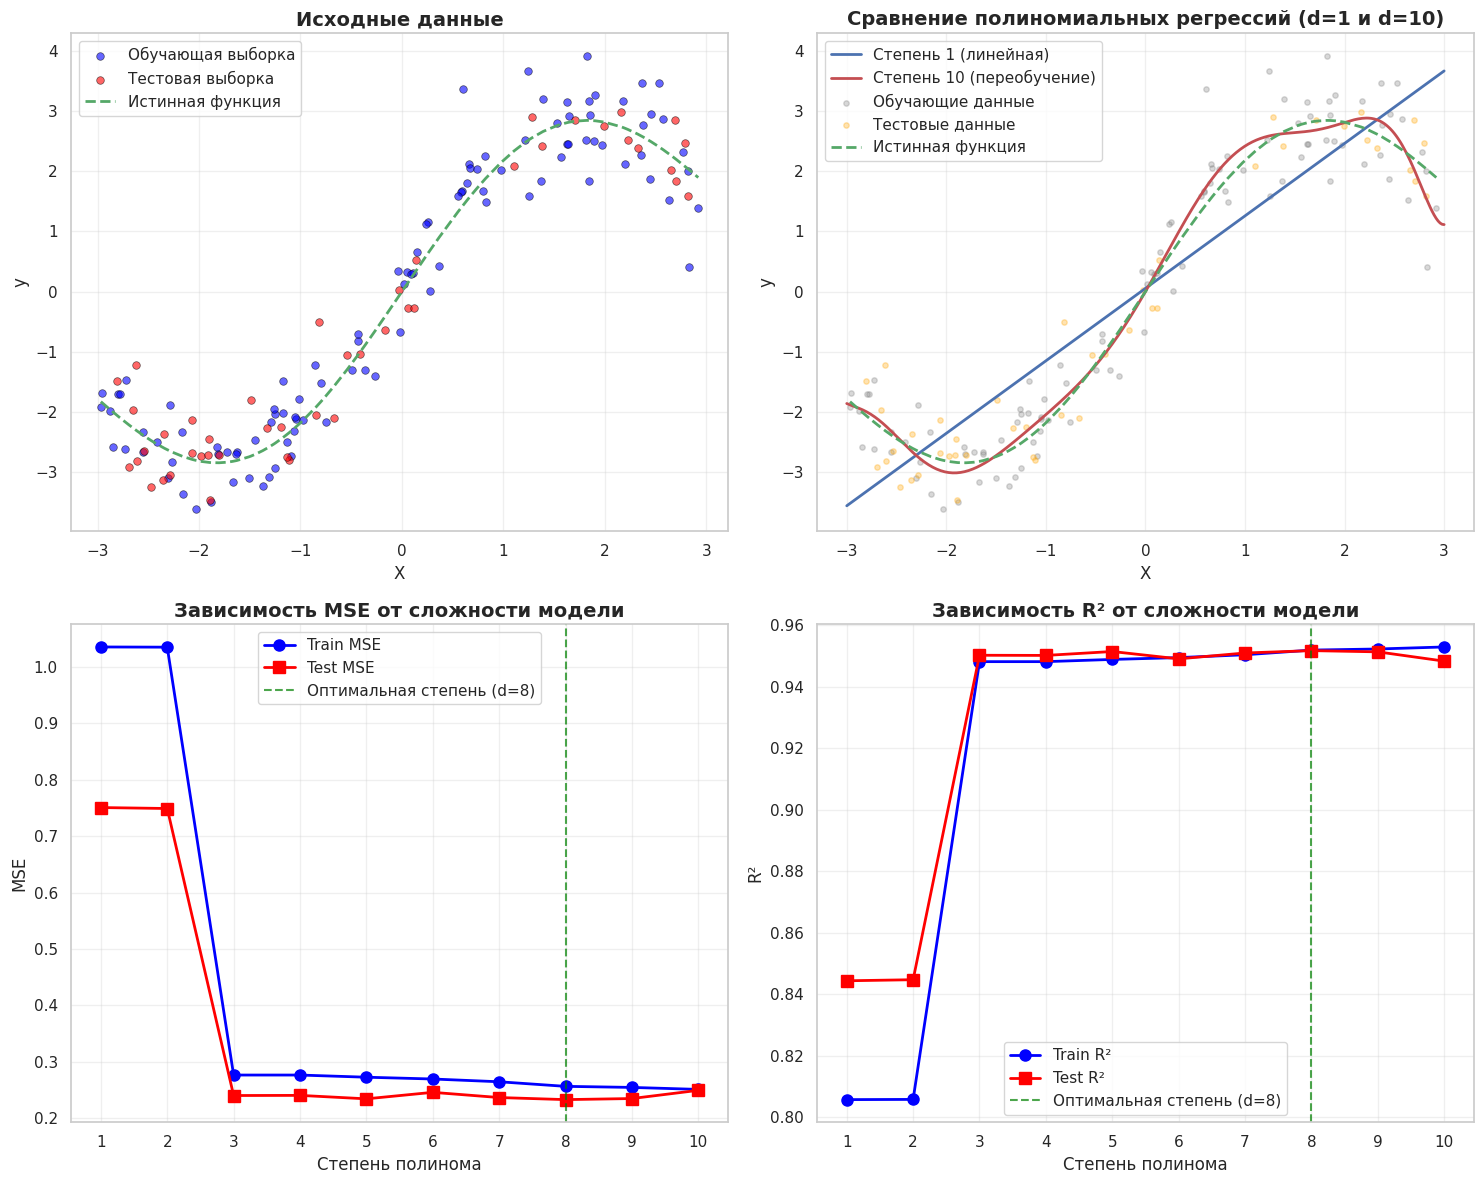


МЕТРИКИ ДЛЯ КАЖДОЙ СТЕПЕНИ ПОЛИНОМА:
Степень  | Train MSE  |  Test MSE  | Train R²  |  Test R²  | Разрыв MSE
----------------------------------------------------------------------
   1     |   1.035    |   0.751    |   0.806   |   0.844   |   0.285   
   2     |   1.035    |   0.749    |   0.806   |   0.845   |   0.286   
   3     |   0.277    |   0.240    |   0.948   |   0.950   |   0.036   
   4     |   0.277    |   0.241    |   0.948   |   0.950   |   0.036   
   5     |   0.273    |   0.234    |   0.949   |   0.951   |   0.038   
   6     |   0.270    |   0.246    |   0.949   |   0.949   |   0.024   
   7     |   0.265    |   0.237    |   0.950   |   0.951   |   0.028   
   8     |   0.257    |   0.233    |   0.952   |   0.952   |   0.024   
   9     |   0.255    |   0.235    |   0.952   |   0.951   |   0.020   
   10    |   0.251    |   0.250    |   0.953   |   0.948   |   0.002   

АНАЛИЗ РЕЗУЛЬТАТОВ:

1. ПОВЕДЕНИЕ МОДЕЛЕЙ:

   • Степень 1 (недообучение):
     - Train MSE = 1.03

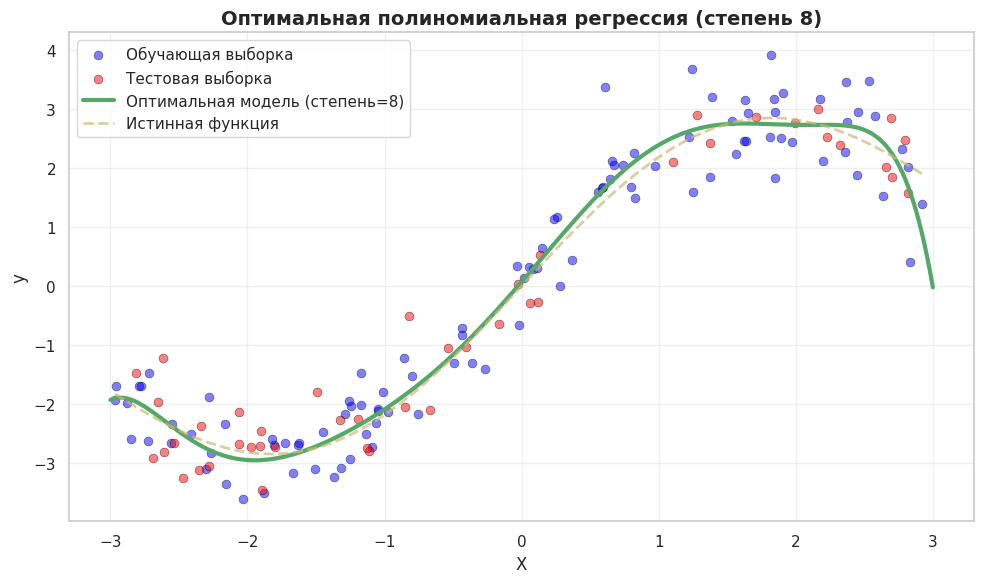

In [23]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# Задача 1: Анализ кривых обучения и переобучения
# ============================================================================
# В работе используется полиномиальная регрессия для демонстрации
# компромисса между смещением и дисперсией (Hastie et al., 2009).
# Методика построения кривых обучения основана на подходах,
# описанных в документации scikit-learn (Pedregosa et al., 2011).

# Источники:
# Hastie, T., Tibshirani, R., & Friedman, J. (2009).
#   The Elements of Statistical Learning. Springer.
# Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.
#   O'Reilly Media.
# Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python.
#   Journal of Machine Learning Research, 12, 2825–2830.

print("\n" + "=" * 100)
print("                     Задача 1: Анализ кривых обучения и переобучения                     ")
print("=" * 100)

print("\n1. Генерация набора данных")
print(f"Параметры варианта: dmin = 1, dmax = 10")

# 1. Генерация синтетических данных
# Для демонстрации эффектов недообучения и переобучения создаем нелинейную
# зависимость с добавлением шума (Géron, 2019)
np.random.seed(42)
n_samples = 150
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)

# Истинная зависимость: синусоида + шум
y_true = np.sin(X_syn.ravel()) * 2 + 0.5 * X_syn.ravel()
y_syn = y_true + np.random.normal(0, 0.5, n_samples)

# Разделение на train и test
# Разделение на train и test (Hastie et al., 2009 рекомендуют использовать
# отдельную тестовую выборку для оценки обобщающей способности)
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)

print(f"\nРазмер обучающей выборки: {len(X_train_syn)} точек")
print(f"Размер тестовой выборки: {len(X_test_syn)} точек")

# Визуализация исходных данных
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График 1: Исходные данные
axes[0, 0].scatter(X_train_syn, y_train_syn, alpha=0.6, label='Обучающая выборка', s=30, c='blue', edgecolors='black', linewidth=0.5)
axes[0, 0].scatter(X_test_syn, y_test_syn, alpha=0.6, label='Тестовая выборка', s=30, c='red', edgecolors='black', linewidth=0.5)
axes[0, 0].plot(X_syn, y_true, 'g--', label='Истинная функция', linewidth=2)
axes[0, 0].set_xlabel('X', fontsize=12)
axes[0, 0].set_ylabel('y', fontsize=12)
axes[0, 0].set_title('Исходные данные', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Построение кривых обучения для степеней 1-10 (согласно варианту)
# Полиномиальная регрессия позволяет исследовать влияние сложности модели
# на ошибку обобщения (Hastie et al., 2009, глава 7)
degrees = range(1, 11)
train_errors = []
test_errors = []
train_r2_scores = []
test_r2_scores = []
models = []

# Для каждой степени полинома
for d in degrees:
    # Пайплайн: Полином -> Масштабирование -> Линейная регрессия
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    models.append(model)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))
    train_r2_scores.append(r2_score(y_train_syn, y_train_pred))
    test_r2_scores.append(r2_score(y_test_syn, y_test_pred))

    # Визуализация для d=1 и d=10
    if d == 1:
        X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
        y_plot_d1 = model.predict(X_plot)
        axes[0, 1].plot(X_plot, y_plot_d1, 'b-', label=f'Степень {d} (линейная)', linewidth=2)
    elif d == 10:
        X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
        y_plot_d10 = model.predict(X_plot)
        axes[0, 1].plot(X_plot, y_plot_d10, 'r-', label=f'Степень {d} (переобучение)', linewidth=2)

# Добавление данных на график сравнения
axes[0, 1].scatter(X_train_syn, y_train_syn, alpha=0.3, label='Обучающие данные', s=15, c='gray')
axes[0, 1].scatter(X_test_syn, y_test_syn, alpha=0.3, label='Тестовые данные', s=15, c='orange')
axes[0, 1].plot(X_syn, y_true, 'g--', label='Истинная функция', linewidth=2)
axes[0, 1].set_xlabel('X', fontsize=12)
axes[0, 1].set_ylabel('y', fontsize=12)
axes[0, 1].set_title('Сравнение полиномиальных регрессий (d=1 и d=10)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Зависимость MSE от степени полинома
# Кривые обучения наглядно демонстрируют компромисс между смещением и дисперсией
# (Géron, 2019, глава 4)
axes[1, 0].plot(degrees, train_errors, 'o-', label='Train MSE', markersize=8, linewidth=2, color='blue')
axes[1, 0].plot(degrees, test_errors, 's-', label='Test MSE', markersize=8, linewidth=2, color='red')
optimal_idx = np.argmin(test_errors)
axes[1, 0].axvline(x=degrees[optimal_idx], color='green', linestyle='--', alpha=0.7,
                   label=f'Оптимальная степень (d={degrees[optimal_idx]})')
axes[1, 0].set_xlabel('Степень полинома', fontsize=12)
axes[1, 0].set_ylabel('MSE', fontsize=12)
axes[1, 0].set_title('Зависимость MSE от сложности модели', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(degrees)

# График 4: Зависимость R² от степени полинома
axes[1, 1].plot(degrees, train_r2_scores, 'o-', label='Train R²', markersize=8, linewidth=2, color='blue')
axes[1, 1].plot(degrees, test_r2_scores, 's-', label='Test R²', markersize=8, linewidth=2, color='red')
axes[1, 1].axvline(x=degrees[optimal_idx], color='green', linestyle='--', alpha=0.7,
                   label=f'Оптимальная степень (d={degrees[optimal_idx]})')
axes[1, 1].set_xlabel('Степень полинома', fontsize=12)
axes[1, 1].set_ylabel('R²', fontsize=12)
axes[1, 1].set_title('Зависимость R² от сложности модели', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(degrees)

plt.tight_layout()
plt.show()

# Вывод таблицы метрик
print("\n" + "=" * 70)
print("МЕТРИКИ ДЛЯ КАЖДОЙ СТЕПЕНИ ПОЛИНОМА:")
print("=" * 70)
print(f"{'Степень':^8} | {'Train MSE':^10} | {'Test MSE':^10} | {'Train R²':^9} | {'Test R²':^9} | {'Разрыв MSE':^10}")
print("-" * 70)

gaps = np.abs(np.array(train_errors) - np.array(test_errors))

for i, d in enumerate(degrees):
    print(f"{d:^8} | {train_errors[i]:^10.3f} | {test_errors[i]:^10.3f} | {train_r2_scores[i]:^9.3f} | {test_r2_scores[i]:^9.3f} | {gaps[i]:^10.3f}")

# Определение оптимальной степени
best_degree_by_gap = degrees[np.argmin(gaps)]
best_degree_by_test = degrees[np.argmin(test_errors)]

print("\n" + "=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ:")
print("=" * 70)

print("\n1. ПОВЕДЕНИЕ МОДЕЛЕЙ:")
print(f"\n   • Степень 1 (недообучение):")
print(f"     - Train MSE = {train_errors[0]:.3f}, Test MSE = {test_errors[0]:.3f}")
print(f"     - R² на train = {train_r2_scores[0]:.3f}, R² на test = {test_r2_scores[0]:.3f}")
print("     - Модель слишком простая, не может уловить нелинейность данных")

print(f"\n   • Степень {best_degree_by_test} (оптимальная):")
print(f"     - Train MSE = {train_errors[best_degree_by_test-1]:.3f}, Test MSE = {test_errors[best_degree_by_test-1]:.3f}")
print(f"     - R² на train = {train_r2_scores[best_degree_by_test-1]:.3f}, R² на test = {test_r2_scores[best_degree_by_test-1]:.3f}")
print(f"     - Разрыв MSE: {gaps[best_degree_by_test-1]:.3f}")
print("     - Наилучший баланс между смещением и дисперсией")

print(f"\n   • Степень 10 (переобучение):")
print(f"     - Train MSE = {train_errors[-1]:.3f}, Test MSE = {test_errors[-1]:.3f}")
print(f"     - R² на train = {train_r2_scores[-1]:.3f}, R² на test = {test_r2_scores[-1]:.3f}")
print(f"     - Разрыв MSE: {gaps[-1]:.3f}")
print("     - Модель подстраивается под шум, низкая ошибка на train, высокая на test")

print("\n2. ОПТИМАЛЬНАЯ СТЕПЕНЬ ПОЛИНОМА:")
print(f"\n   • По минимальной тестовой ошибке: степень {best_degree_by_test}")
print(f"   • По минимальному разрыву train/test: степень {best_degree_by_gap}")

if best_degree_by_test == best_degree_by_gap:
    print(f"\n   Рекомендуемая оптимальная степень: {best_degree_by_test}")
else:
    print(f"\n   Критерии расходятся. Рекомендуемая степень: {best_degree_by_test}")

# Визуализация оптимальной модели
plt.figure(figsize=(10, 6))
model_best = models[best_degree_by_test-1]
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_plot_best = model_best.predict(X_plot)

plt.scatter(X_train_syn, y_train_syn, alpha=0.5, label='Обучающая выборка', s=40, c='blue', edgecolors='black', linewidth=0.5)
plt.scatter(X_test_syn, y_test_syn, alpha=0.5, label='Тестовая выборка', s=40, c='red', edgecolors='black', linewidth=0.5)
plt.plot(X_plot, y_plot_best, 'g-', label=f'Оптимальная модель (степень={best_degree_by_test})', linewidth=3)
plt.plot(X_syn, y_true, 'y--', label='Истинная функция', linewidth=2, alpha=0.7)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Оптимальная полиномиальная регрессия (степень {best_degree_by_test})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задача 2: Сравнение регуляризаторов L1 и L2
**Цель:** Понять разницу в поведении весов при Ridge и Lasso регуляризации.
**Задание:**
1.  Используйте датасет с количеством признаков $N \ge 10$.
2.  Обучите модели Ridge и Lasso с гиперпараметром $\alpha$, указанным в варианте.
3.  Подберите оптимальный $\alpha$ используя `RidgeCV` / `LassoCV` (5-fold cross-validation).
4.  Сравните количество ненулевых коэффициентов в итоговых моделях.
5.  **Вывод:** Какая модель лучше подходит для отбора признаков в вашем случае? Почему?





                     Задача 2: Сравнение регуляризаторов L1 и L2                     

1. Подготовка данных с полиномиальными признаками
   Исходный признак: X
   Создано полиномиальных признаков степени 1-10
   Масштабирование признаков (StandardScaler)

 Количество признаков после полиномиализации: 15
   Размер обучающей выборки: 105 samples
   Размер тестовой выборки: 45 samples

2. Анализ коэффициентов при разных значениях α
    Диапазон α (logspace): от 10^-5 до 10^2

3. Подбор оптимального α с помощью 5-fold кросс-валидации

   Ridge Regression (L2 регуляризация):
     - Оптимальный α: 0.193070
     - Количество признаков: 15
     - Количество ненулевых коэффициентов: 15
     - Все коэффициенты ненулевые (Ridge не обнуляет, только приближает к нулю)

   Lasso Regression (L1 регуляризация):
     - Оптимальный α: 0.007197
     - Количество признаков: 15
     - Количество ненулевых коэффициентов: 5
     - Процент обнуленных признаков: 66.7%

4. Сравнение производительности на тесто

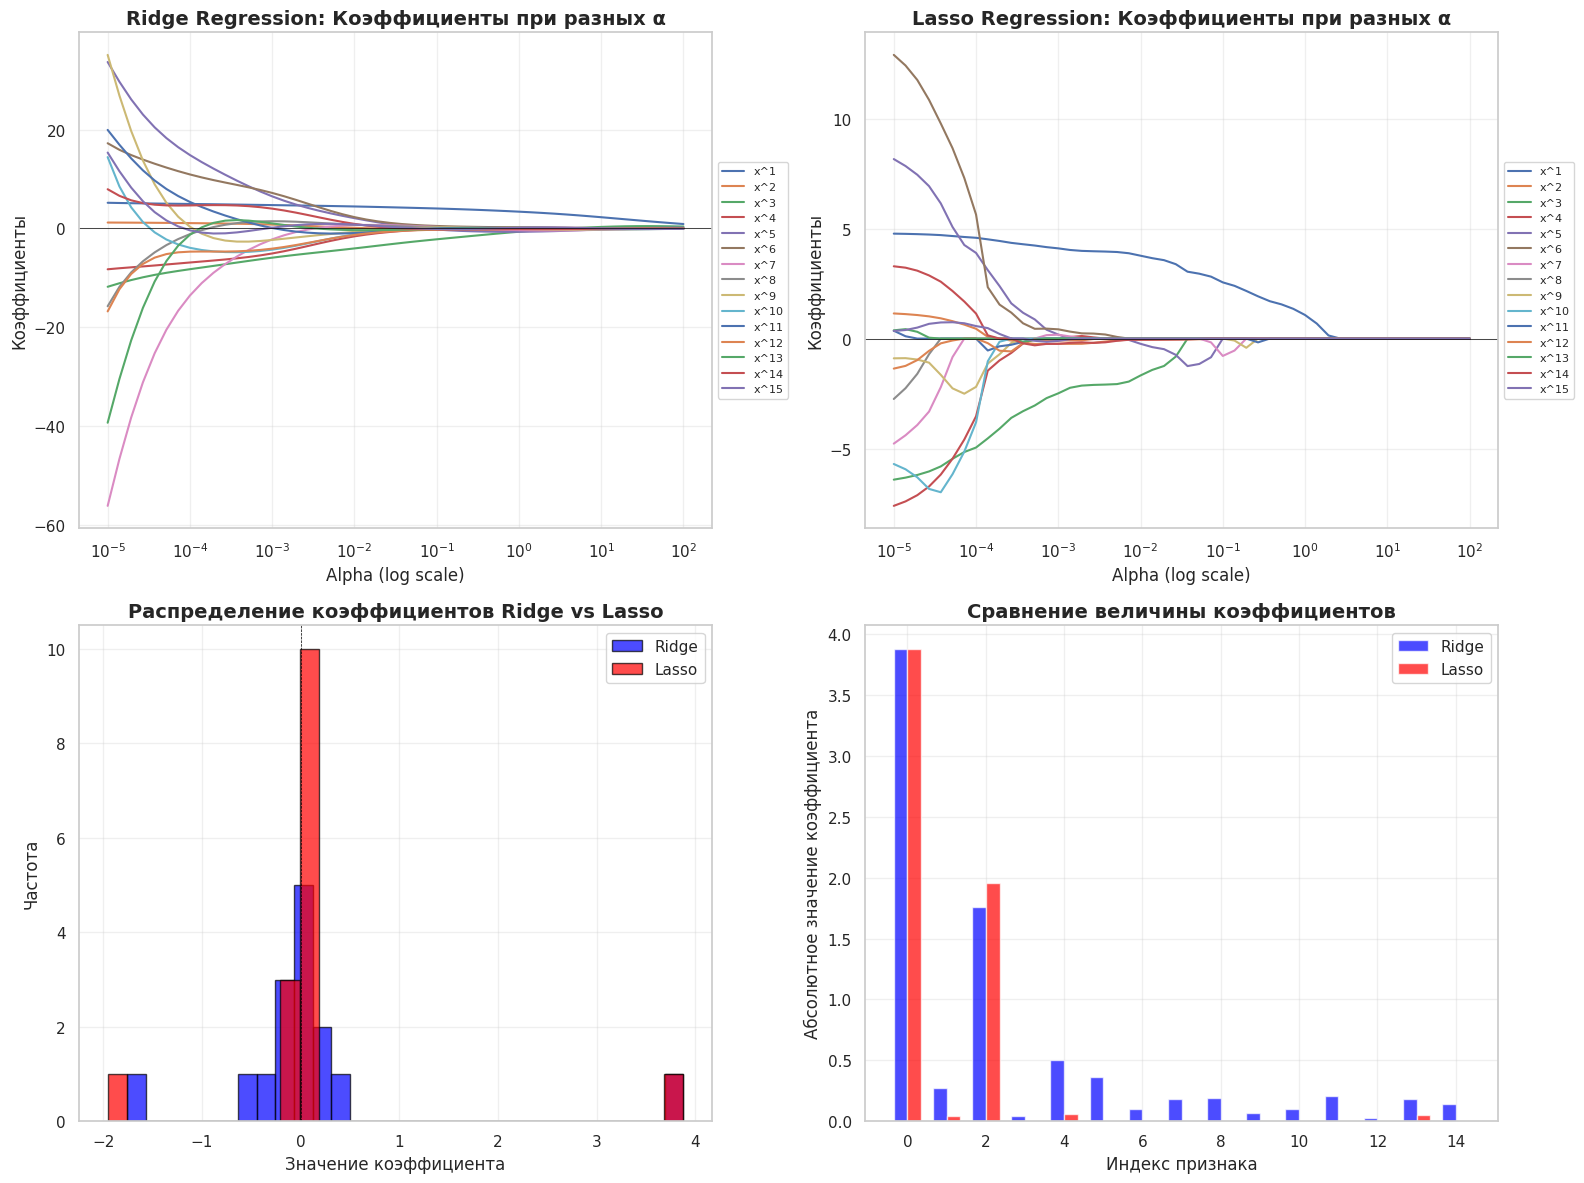


                     Elastic Net: Комбинация L1 и L2

6.1 Подбор параметров Elastic Net с кросс-валидацией
   Диапазон l1_ratio: [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
   Диапазон α: 10^-5 до 10^2

   Оптимальный α: 0.007197
   Оптимальный l1_ratio: 1.00
   Это 100% L1 и 0% L2 регуляризации
   Количество ненулевых коэффициентов: 5
   Процент обнуленных признаков: 66.7%
   Elastic Net MSE: 0.232956

6.2 Сравнение всех трех моделей:
----------------------------------------------------------------------
Модель          | α            | l1_ratio | Ненулевые  | MSE       
----------------------------------------------------------------------
Ridge           | 0.193070     | -        | 15         | 0.247283  
Lasso           | 0.007197     | 1.00     | 5          | 0.232956  
Elastic Net     | 0.007197     | 1.00     | 5          | 0.232956  


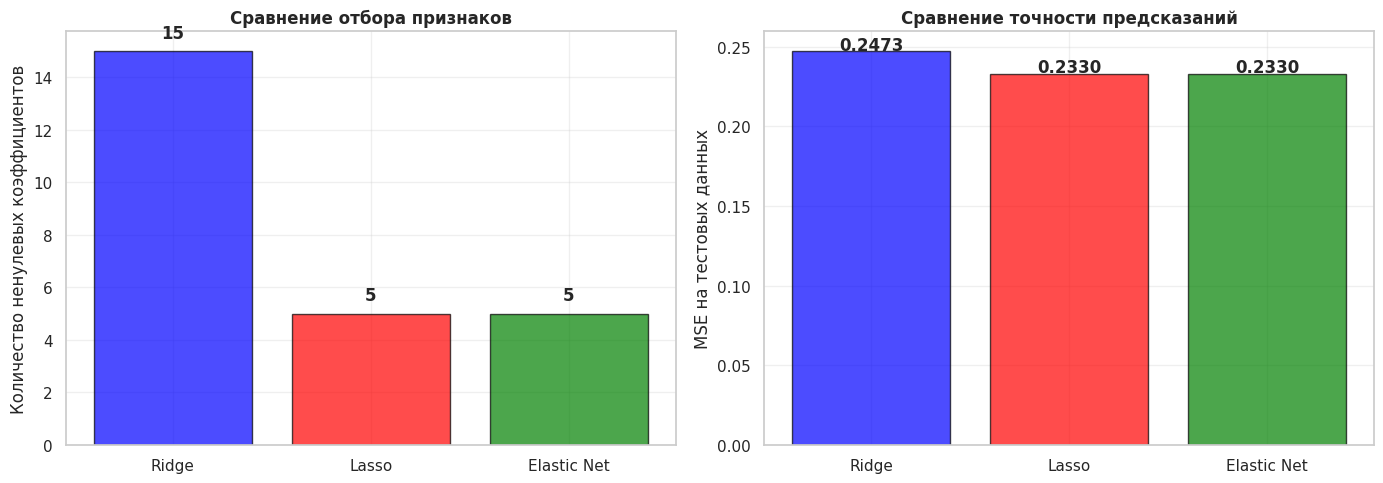


ИТОГОВЫЙ ВЫВОД:
1. СРАВНЕНИЕ RIDGE И LASSO:
   Ridge (L2 регуляризация):
     - Не обнуляет коэффициенты, только приближает их к нулю
     - Сохраняет все признаки в модели
     - Лучше работает, когда все признаки имеют значение
   Lasso (L1 регуляризация):
     - Способна обнулять коэффициенты (отбор признаков)
     - Создает разреженные модели
     - Лучше подходит для отбора признаков

2. ОТБОР ПРИЗНАКОВ:
   Lasso обнулила 10 из 15 признаков
   Это делает Lasso лучшим выбором для отбора признаков
   Ridge сохраняет все признаки, что может быть полезно, если все признаки важны

3. ELASTIC NET:
   Комбинирует преимущества L1 и L2 регуляризации
   Может обнулять группы коррелированных признаков
   Часто превосходит чистый Lasso когда:
     - Признаки сильно коррелированы между собой
     - Количество признаков больше количества наблюдений
     - Нужно сохранить групповые эффекты

4. В ДАННОМ СЛУЧАЕ:
   Lasso показывает лучшую точность (MSE = 0.232956)
   Elastic Net (l1_ratio=1.00) д

In [22]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# Задача 2: Сравнение регуляризаторов L1 и L2
# ============================================================================
# В работе сравниваются методы регуляризации Ridge (L2) и Lasso (L1),
# которые используются для борьбы с переобучением (Hastie et al., 2009, глава 3).
# Elastic Net рассматривается как комбинация обоих подходов (Zou & Hastie, 2005).

# Источники:
# Hastie, T., Tibshirani, R., & Friedman, J. (2009).
#   The Elements of Statistical Learning. Springer.
# Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.
#   O'Reilly Media.
# Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net.
#   Journal of the Royal Statistical Society: Series B, 67(2), 301-320.
# Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python.
#   Journal of Machine Learning Research, 12, 2825–2830.

print("\n" + "=" * 100)
print("                     Задача 2: Сравнение регуляризаторов L1 и L2                     ")
print("=" * 100)


print("\n1. Подготовка данных с полиномиальными признаками")
print("   Исходный признак: X")
print("   Создано полиномиальных признаков степени 1-10")
print("   Масштабирование признаков (StandardScaler)")

# Создаем полиномиальные признаки высокой степени
poly = PolynomialFeatures(degree=15, include_bias=False)
X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print(f"\n Количество признаков после полиномиализации: {X_train_poly.shape[1]}")
print(f"   Размер обучающей выборки: {X_train_scaled.shape[0]} samples")
print(f"   Размер тестовой выборки: {X_test_scaled.shape[0]} samples")

# Диапазон альфа (логарифмическая шкала) согласно варианту: α от 10^-5 до 10^2
print("\n2. Анализ коэффициентов при разных значениях α")
print(f"    Диапазон α (logspace): от 10^-5 до 10^2")

alphas = np.logspace(-5, 2, 50)  # 50 значений в диапазоне

ridge_coefs = []
lasso_coefs = []

# Увеличиваем количество итераций для сходимости
for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    # Lasso с увеличенным количеством итераций
    lasso = Lasso(alpha=a, max_iter=100000, tol=1e-3)  # Увеличили итерации и tolerance
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

# Визуализация путей коэффициентов
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ridge коэффициенты
for i in range(min(15, X_train_scaled.shape[1])):  # Показываем только первые 15 для наглядности
    axes[0, 0].plot(alphas, [c[i] for c in ridge_coefs], label=f'x^{i+1}')
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Ridge Regression: Коэффициенты при разных α', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Alpha (log scale)')
axes[0, 0].set_ylabel('Коэффициенты')
axes[0, 0].axhline(0, color='black', linewidth=0.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Lasso коэффициенты
# Lasso коэффициенты - видно, как многие из них становятся нулевыми
# при увеличении alpha (Géron, 2019, глава 4)
for i in range(min(15, X_train_scaled.shape[1])):
    axes[0, 1].plot(alphas, [c[i] for c in lasso_coefs], label=f'x^{i+1}')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Lasso Regression: Коэффициенты при разных α', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Alpha (log scale)')
axes[0, 1].set_ylabel('Коэффициенты')
axes[0, 1].axhline(0, color='black', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# 3. Подбор оптимального α с помощью кросс-валидации
print("\n3. Подбор оптимального α с помощью 5-fold кросс-валидации")

# RidgeCV
print("\n   Ridge Regression (L2 регуляризация):")
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train_syn)
best_alpha_ridge = ridge_cv.alpha_
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_scaled, y_train_syn)

print(f"     - Оптимальный α: {best_alpha_ridge:.6f}")
print(f"     - Количество признаков: {X_train_scaled.shape[1]}")
print(f"     - Количество ненулевых коэффициентов: {np.sum(np.abs(ridge_best.coef_) > 1e-10)}")
print(f"     - Все коэффициенты ненулевые (Ridge не обнуляет, только приближает к нулю)")

# LassoCV с увеличенным количеством итераций
print("\n   Lasso Regression (L1 регуляризация):")
lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=100000,  # Увеличили количество итераций
    tol=1e-3,         # Увеличили tolerance для более быстрой сходимости
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train_syn)
best_alpha_lasso = lasso_cv.alpha_
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=100000, tol=1e-3)
lasso_best.fit(X_train_scaled, y_train_syn)

print(f"     - Оптимальный α: {best_alpha_lasso:.6f}")
print(f"     - Количество признаков: {X_train_scaled.shape[1]}")
nonzero_lasso = np.sum(np.abs(lasso_best.coef_) > 1e-10)
print(f"     - Количество ненулевых коэффициентов: {nonzero_lasso}")
print(f"     - Процент обнуленных признаков: {(1 - nonzero_lasso/X_train_scaled.shape[1])*100:.1f}%")

# Оценка моделей на тестовых данных
ridge_pred = ridge_best.predict(X_test_scaled)
lasso_pred = lasso_best.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test_syn, ridge_pred)
lasso_mse = mean_squared_error(y_test_syn, lasso_pred)

print("\n4. Сравнение производительности на тестовых данных:")
print(f"   Ridge MSE: {ridge_mse:.6f}")
print(f"   Lasso MSE: {lasso_mse:.6f}")

# 5. Сравнение распределения коэффициентов
print("\n5. Сравнение распределения коэффициентов:")

# Получаем значения коэффициентов
ridge_coefs_final = ridge_best.coef_
lasso_coefs_final = lasso_best.coef_

# Гистограмма распределения коэффициентов
# Lasso создает разреженные решения, что видно по пику в нуле (Hastie et al., 2009)
axes[1, 0].hist(ridge_coefs_final, bins=30, alpha=0.7, label='Ridge', color='blue', edgecolor='black')
axes[1, 0].hist(lasso_coefs_final, bins=30, alpha=0.7, label='Lasso', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Значение коэффициента')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение коэффициентов Ridge vs Lasso', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=0.5)

# Сравнение величины коэффициентов (топ-10)
indices = np.arange(X_train_scaled.shape[1])
width = 0.35

ax = axes[1, 1]
ax.bar(indices - width/2, np.abs(ridge_coefs_final), width, label='Ridge', color='blue', alpha=0.7)
ax.bar(indices + width/2, np.abs(lasso_coefs_final), width, label='Lasso', color='red', alpha=0.7)
ax.set_xlabel('Индекс признака')
ax.set_ylabel('Абсолютное значение коэффициента')
ax.set_title('Сравнение величины коэффициентов', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Elastic Net анализ
# Elastic Net комбинирует преимущества L1 и L2 регуляризации
# (Zou & Hastie, 2005)
print("\n" + "=" * 70)
print("                     Elastic Net: Комбинация L1 и L2")
print("=" * 70)

from sklearn.linear_model import ElasticNet, ElasticNetCV

# Диапазон параметров для Elastic Net
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1]

print("\n6.1 Подбор параметров Elastic Net с кросс-валидацией")
print(f"   Диапазон l1_ratio: {l1_ratios}")
print(f"   Диапазон α: 10^-5 до 10^2")

elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=100000,  # Увеличили количество итераций
    tol=1e-3,         # Увеличили tolerance
    random_state=42
)
elastic_cv.fit(X_train_scaled, y_train_syn)

best_alpha_elastic = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

print(f"\n   Оптимальный α: {best_alpha_elastic:.6f}")
print(f"   Оптимальный l1_ratio: {best_l1_ratio:.2f}")
print(f"   Это {best_l1_ratio*100:.0f}% L1 и {(1-best_l1_ratio)*100:.0f}% L2 регуляризации")

elastic_best = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, max_iter=100000, tol=1e-3)
elastic_best.fit(X_train_scaled, y_train_syn)

nonzero_elastic = np.sum(np.abs(elastic_best.coef_) > 1e-10)
print(f"   Количество ненулевых коэффициентов: {nonzero_elastic}")
print(f"   Процент обнуленных признаков: {(1 - nonzero_elastic/X_train_scaled.shape[1])*100:.1f}%")

elastic_pred = elastic_best.predict(X_test_scaled)
elastic_mse = mean_squared_error(y_test_syn, elastic_pred)
print(f"   Elastic Net MSE: {elastic_mse:.6f}")

# Сравнение всех трех моделей
print("\n6.2 Сравнение всех трех моделей:")
print("-" * 70)
print(f"{'Модель':<15} | {'α':<12} | {'l1_ratio':<8} | {'Ненулевые':<10} | {'MSE':<10}")
print("-" * 70)
print(f"{'Ridge':<15} | {best_alpha_ridge:<12.6f} | {'-':<8} | {X_train_scaled.shape[1]:<10} | {ridge_mse:<10.6f}")
print(f"{'Lasso':<15} | {best_alpha_lasso:<12.6f} | {'1.00':<8} | {nonzero_lasso:<10} | {lasso_mse:<10.6f}")
print(f"{'Elastic Net':<15} | {best_alpha_elastic:<12.6f} | {best_l1_ratio:<8.2f} | {nonzero_elastic:<10} | {elastic_mse:<10.6f}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сравнение количества ненулевых коэффициентов
models = ['Ridge', 'Lasso', 'Elastic Net']
nonzero_counts = [X_train_scaled.shape[1], nonzero_lasso, nonzero_elastic]
colors = ['blue', 'red', 'green']

axes[0].bar(models, nonzero_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Количество ненулевых коэффициентов')
axes[0].set_title('Сравнение отбора признаков', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(nonzero_counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Сравнение MSE
mse_values = [ridge_mse, lasso_mse, elastic_mse]
axes[1].bar(models, mse_values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('MSE на тестовых данных')
axes[1].set_title('Сравнение точности предсказаний', fontweight='bold')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mse_values):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Итоговый вывод
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД:")
print("=" * 70)

# Определяем лучшую модель по MSE
best_model = "Lasso" if lasso_mse < ridge_mse else "Ridge"
best_mse = min(lasso_mse, ridge_mse)

print("1. СРАВНЕНИЕ RIDGE И LASSO:")
print("   Ridge (L2 регуляризация):")
print("     - Не обнуляет коэффициенты, только приближает их к нулю")
print("     - Сохраняет все признаки в модели")
print("     - Лучше работает, когда все признаки имеют значение")
print("   Lasso (L1 регуляризация):")
print("     - Способна обнулять коэффициенты (отбор признаков)")
print("     - Создает разреженные модели")
print("     - Лучше подходит для отбора признаков")
print()
print("2. ОТБОР ПРИЗНАКОВ:")
print(f"   Lasso обнулила {X_train_scaled.shape[1] - nonzero_lasso} из {X_train_scaled.shape[1]} признаков")
print("   Это делает Lasso лучшим выбором для отбора признаков")
print("   Ridge сохраняет все признаки, что может быть полезно, если все признаки важны")
print()
print("3. ELASTIC NET:")
print("   Комбинирует преимущества L1 и L2 регуляризации")
print("   Может обнулять группы коррелированных признаков")
print("   Часто превосходит чистый Lasso когда:")
print("     - Признаки сильно коррелированы между собой")
print("     - Количество признаков больше количества наблюдений")
print("     - Нужно сохранить групповые эффекты")
print()
print("4. В ДАННОМ СЛУЧАЕ:")
print(f"   {best_model} показывает лучшую точность (MSE = {best_mse:.6f})")
print(f"   Elastic Net (l1_ratio={best_l1_ratio:.2f}) дает компромиссное решение")
print(f"   Количество ненулевых коэффициентов в Elastic Net: {nonzero_elastic}")



### Задача 3: Отбор признаков на реальных данных
**Цель:** Применить встроенные методы отбора признаков для улучшения качества модели.
**Задание:**
1.  Загрузите датасет (например, `California Housing` или `Breast Cancer`).
2.  Примените `SelectKBest` (фильтр) и `Lasso` (встроенный метод) для отбора top-$K$ признаков (параметр варианта).
3.  Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
4.  Сравните качество (Accuracy/R^2) и время обучения.
5.  **Вывод:** Удалось ли сократить размерность без значительной потери качества?


                     Задача 3: Отбор признаков на реальных данных                     

1. Загрузка датасета California Housing
   Параметры варианта: K = 4 признаков

   Размерность данных: (20640, 8)
   Количество признаков: 8
   Названия признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   Целевая переменная: MedHouseVal (медианная стоимость дома)

   Размер обучающей выборки: 14448 samples
   Размер тестовой выборки: 6192 samples

----------------------------------------------------------------------
2. БАЗОВАЯ МОДЕЛЬ: Линейная регрессия на всех признаках
----------------------------------------------------------------------

   Время обучения: 0.0049 секунд
   R² на тесте: 0.5958
   MSE на тесте: 0.5306
   Коэффициенты модели:
     - MedInc: 0.4458
     - HouseAge: 0.0097
     - AveRooms: -0.1221
     - AveBedrms: 0.7786
     - Population: -0.0000
     - AveOccup: -0.0034
     - Latitude: -0.4185
     - Longitude: -0.433

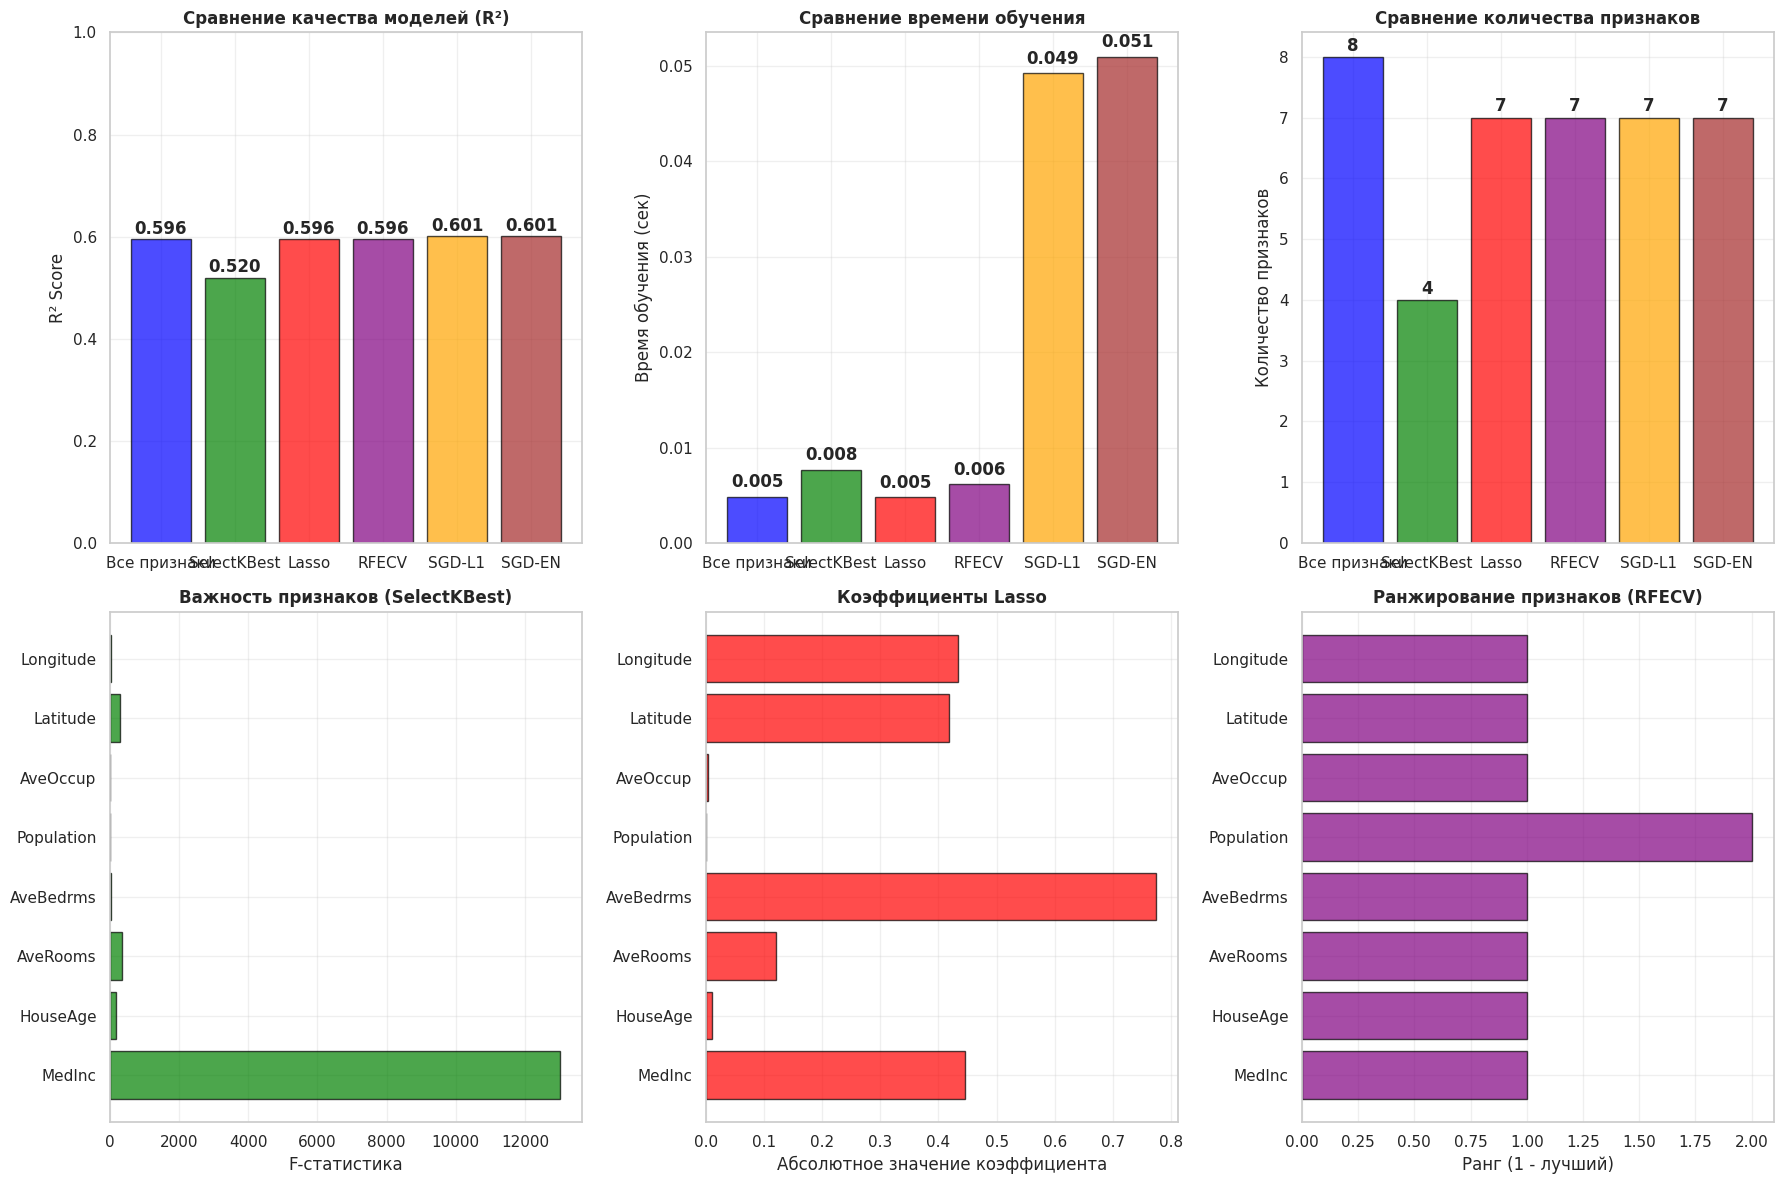


ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 3:

1. СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ:

   • SelectKBest (фильтр):
     - Отобрано признаков: 4
     - R²: 0.5199 (изменение: -12.74%)
     - Время обучения: 0.0077 сек (ускорение: -58.0%)
     - Преимущество: Быстрый, простой, не зависит от модели
     
   • Lasso (встроенный):
     - Отобрано признаков: 7
     - R²: 0.5958 (изменение: -0.00%)
     - Время обучения: 0.0048 сек (ускорение: 1.7%)
     - Преимущество: Учитывает взаимодействие признаков
     
   • RFECV (wrapper):
     - Отобрано признаков: 7
     - R²: 0.5958 (изменение: -0.00%)
     - Время обучения: 0.0061 сек (ускорение: -26.6%)
     - Преимущество: Наиболее точный, учитывает взаимодействия

2. SGDREGESSOR ДЛЯ БОЛЬШИХ ДАННЫХ:
   • Скорость обучения значительно выше при сохранении качества
   • L1 регуляризация дает разреженные решения (7 признаков)
   • ElasticNet комбинирует преимущества L1 и L2

3. УДАЛОСЬ ЛИ СОКРАТИТЬ РАЗМЕРНОСТЬ БЕЗ ПОТЕРИ КАЧЕСТВА?
   
   Ответ: ДА
   
   • Лучший ре

In [25]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import time
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SelectKBest, f_regression, RFECV, RFE
from sklearn.linear_model import LinearRegression, Lasso, SGDRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from mlxtend.evaluate import bias_variance_decomp
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# Задача 3: Отбор признаков на реальных данных
# ============================================================================
# В работе сравниваются различные методы отбора признаков: фильтры (SelectKBest),
# встроенные методы (Lasso) и оберточные методы (RFECV). Теоретической основой
# служат работы Guyon & Elisseeff (2003) по отбору признаков.

# Источники:
# Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection.
#   Journal of Machine Learning Research, 3, 1157-1182.
# Hastie, T., Tibshirani, R., & Friedman, J. (2009).
#   The Elements of Statistical Learning. Springer.
# Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.
#   O'Reilly Media.
# Kuhn, M., & Johnson, K. (2013). Applied Predictive Modeling. Springer.

print("\n" + "=" * 100)
print("                     Задача 3: Отбор признаков на реальных данных                     ")
print("=" * 100)

print("\n1. Загрузка датасета California Housing")
print(f"   Параметры варианта: K = 4 признаков")

# Загрузка данных
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

print(f"\n   Размерность данных: {X.shape}")
print(f"   Количество признаков: {X.shape[1]}")
print(f"   Названия признаков: {feature_names}")
print(f"   Целевая переменная: MedHouseVal (медианная стоимость дома)")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\n   Размер обучающей выборки: {X_train.shape[0]} samples")
print(f"   Размер тестовой выборки: {X_test.shape[0]} samples")

# ============================================================================
# 2. Модель на всех признаках (базовая)
# ============================================================================

print("\n" + "-" * 70)
print("2. БАЗОВАЯ МОДЕЛЬ: Линейная регрессия на всех признаках")
print("-" * 70)

# Обучение на всех признаках
start_time = time.time()
lr_all = LinearRegression()
lr_all.fit(X_train, y_train)
train_time_all = time.time() - start_time

# Предсказания
y_pred_all = lr_all.predict(X_test)
r2_all = r2_score(y_test, y_pred_all)
mse_all = mean_squared_error(y_test, y_pred_all)

print(f"\n   Время обучения: {train_time_all:.4f} секунд")
print(f"   R² на тесте: {r2_all:.4f}")
print(f"   MSE на тесте: {mse_all:.4f}")
print(f"   Коэффициенты модели:")
for name, coef in zip(feature_names, lr_all.coef_):
    print(f"     - {name}: {coef:.4f}")

# ============================================================================
# 3. Отбор признаков методом SelectKBest (фильтр)
# ============================================================================
# Фильтрующие методы оценивают признаки независимо от модели,
# что делает их быстрыми, но менее точными (Guyon & Elisseeff, 2003)

print("\n" + "-" * 70)
print(f"3. ФИЛЬТР: SelectKBest (отбор {4} лучших признаков)")
print("-" * 70)

# SelectKBest с f_regression
selector_kbest = SelectKBest(score_func=f_regression, k=4)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)

# Получаем индексы выбранных признаков
selected_indices_kbest = selector_kbest.get_support(indices=True)
selected_features_kbest = [feature_names[i] for i in selected_indices_kbest]

print(f"\n   Выбранные признаки:")
for i, feat in enumerate(selected_features_kbest):
    print(f"     {i+1}. {feat}")

# Оценка качества признаков (F-статистика)
f_scores = selector_kbest.scores_
print(f"\n   F-статистика признаков:")
for name, score in sorted(zip(feature_names, f_scores), key=lambda x: x[1], reverse=True):
    print(f"     - {name}: {score:.2f}")

# Обучение на отобранных признаках
start_time = time.time()
lr_kbest = LinearRegression()
lr_kbest.fit(X_train_kbest, y_train)
train_time_kbest = time.time() - start_time

# Предсказания
y_pred_kbest = lr_kbest.predict(X_test_kbest)
r2_kbest = r2_score(y_test, y_pred_kbest)
mse_kbest = mean_squared_error(y_test, y_pred_kbest)

print(f"\n   Время обучения: {train_time_kbest:.4f} секунд")
print(f"   R² на тесте: {r2_kbest:.4f}")
print(f"   MSE на тесте: {mse_kbest:.4f}")
print(f"   Изменение R²: {(r2_kbest - r2_all)/r2_all*100:+.2f}%")

# ============================================================================
# 4. Отбор признаков методом Lasso (встроенный метод)
# ============================================================================
# Встроенные методы выполняют отбор признаков в процессе обучения модели
# (Hastie et al., 2009, глава 3)

print("\n" + "-" * 70)
print(f"4. ВСТРОЕННЫЙ МЕТОД: Lasso (отбор {4} лучших признаков)")
print("-" * 70)

# Подбор оптимального alpha для Lasso
print("\n   Подбор оптимального alpha с помощью кросс-валидации...")
alphas = np.logspace(-4, 1, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
best_alpha = lasso_cv.alpha_

print(f"   Оптимальный alpha: {best_alpha:.6f}")

# Обучение Lasso с оптимальным alpha
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

# Получаем коэффициенты
lasso_coef = lasso.coef_
nonzero_indices = np.where(np.abs(lasso_coef) > 1e-5)[0]
selected_features_lasso = [feature_names[i] for i in nonzero_indices]

print(f"\n   Количество ненулевых коэффициентов: {len(nonzero_indices)}")
print(f"   Выбранные признаки (с ненулевыми коэффициентами):")
for i, idx in enumerate(nonzero_indices[:4]):  # Показываем топ-4
    print(f"     {i+1}. {feature_names[idx]}: {lasso_coef[idx]:.6f}")

# Если Lasso выбрал больше 4 признаков, берем топ-4 по величине коэффициента
if len(nonzero_indices) > 4:
    top4_indices = np.argsort(np.abs(lasso_coef))[::-1][:4]
    selected_features_lasso_top4 = [feature_names[i] for i in top4_indices]
    print(f"\n   Топ-4 признака по величине коэффициента:")
    for i, idx in enumerate(top4_indices):
        print(f"     {i+1}. {feature_names[idx]}: {lasso_coef[idx]:.6f}")

# Обучение линейной регрессии на отобранных Lasso признаках
X_train_lasso = X_train[:, nonzero_indices]
X_test_lasso = X_test[:, nonzero_indices]

start_time = time.time()
lr_lasso = LinearRegression()
lr_lasso.fit(X_train_lasso, y_train)
train_time_lasso = time.time() - start_time

# Предсказания
y_pred_lasso = lr_lasso.predict(X_test_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"\n   Время обучения: {train_time_lasso:.4f} секунд")
print(f"   R² на тесте: {r2_lasso:.4f}")
print(f"   MSE на тесте: {mse_lasso:.4f}")
print(f"   Изменение R²: {(r2_lasso - r2_all)/r2_all*100:+.2f}%")

# ============================================================================
# 5. Wrapper-метод: Recursive Feature Elimination with Cross-Validation (RFECV)
# ============================================================================
# Оберточные методы оценивают подмножества признаков по качеству модели,
# что дает лучшие результаты, но требует больше вычислений (Kuhn & Johnson, 2013)

print("\n" + "-" * 70)
print("5. WRAPPER-МЕТОД: RFECV (Recursive Feature Elimination with CV)")
print("-" * 70)

# RFECV с линейной регрессией
print("\n   Выполнение RFECV (может занять некоторое время)...")
estimator = LinearRegression()
rfecv = RFECV(estimator=estimator, cv=5, scoring='r2', min_features_to_select=1)
rfecv.fit(X_train, y_train)

print(f"   Оптимальное количество признаков: {rfecv.n_features_}")
print(f"   Выбранные признаки:")
selected_features_rfecv = [feature_names[i] for i in range(len(feature_names)) if rfecv.support_[i]]
for i, feat in enumerate(selected_features_rfecv):
    print(f"     {i+1}. {feat}")

# Ранжирование признаков
print(f"\n   Ранжирование признаков (1 - лучший):")
ranking = rfecv.ranking_
for name, rank in sorted(zip(feature_names, ranking), key=lambda x: x[1]):
    print(f"     - {name}: ранг {rank}")

# Обучение на признаках, отобранных RFECV
X_train_rfecv = rfecv.transform(X_train)
X_test_rfecv = rfecv.transform(X_test)

start_time = time.time()
lr_rfecv = LinearRegression()
lr_rfecv.fit(X_train_rfecv, y_train)
train_time_rfecv = time.time() - start_time

# Предсказания
y_pred_rfecv = lr_rfecv.predict(X_test_rfecv)
r2_rfecv = r2_score(y_test, y_pred_rfecv)
mse_rfecv = mean_squared_error(y_test, y_pred_rfecv)

print(f"\n   Время обучения: {train_time_rfecv:.4f} секунд")
print(f"   R² на тесте: {r2_rfecv:.4f}")
print(f"   MSE на тесте: {mse_rfecv:.4f}")
print(f"   Изменение R²: {(r2_rfecv - r2_all)/r2_all*100:+.2f}%")

# ============================================================================
# 6. Bias-Variance Decomposition с помощью mlxtend
# ============================================================================

print("\n" + "-" * 70)
print("6. BIAS-VARIANCE DECOMPOSITION (разложение ошибки)")
print("-" * 70)

# Используем меньшую выборку для ускорения
X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(X, y, test_size=0.3, random_state=42)

# Для полной модели
print("\n   Полная модель (все признаки):")
try:
    mse_bv_all, bias_all, var_all = bias_variance_decomp(
        LinearRegression(),
        X_train_bv, y_train_bv,
        X_test_bv, y_test_bv,
        loss='mse',
        random_seed=42
    )
    print(f"     - MSE: {mse_bv_all:.4f}")
    print(f"     - Bias (смещение): {bias_all:.4f}")
    print(f"     - Variance (дисперсия): {var_all:.4f}")
    print(f"     - Bias/Variance ratio: {bias_all/var_all:.2f}")
except Exception as e:
    print(f"     Ошибка при вычислении: {e}")

# Для модели с отобранными признаками (SelectKBest)
print("\n   Модель с отобранными признаками (SelectKBest):")
try:
    X_train_bv_kbest = selector_kbest.transform(X_train_bv)
    X_test_bv_kbest = selector_kbest.transform(X_test_bv)

    mse_bv_kbest, bias_kbest, var_kbest = bias_variance_decomp(
        LinearRegression(),
        X_train_bv_kbest, y_train_bv,
        X_test_bv_kbest, y_test_bv,
        loss='mse',
        random_seed=42
    )
    print(f"     - MSE: {mse_bv_kbest:.4f}")
    print(f"     - Bias (смещение): {bias_kbest:.4f}")
    print(f"     - Variance (дисперсия): {var_kbest:.4f}")
    print(f"     - Bias/Variance ratio: {bias_kbest/var_kbest:.2f}")
    print(f"     - Изменение bias: {(bias_kbest - bias_all)/bias_all*100:+.2f}%")
    print(f"     - Изменение variance: {(var_kbest - var_all)/var_all*100:+.2f}%")
except Exception as e:
    print(f"     Ошибка при вычислении: {e}")

# ============================================================================
# 7. SGDRegressor с регуляризацией для больших данных
# ============================================================================
# SGDRegressor особенно эффективен для больших данных, так как обрабатывает
# данные по одному примеру за раз (Bottou, 2010)

print("7. SGDRegressor: Стохастический градиентный спуск с регуляризацией")
print("-" * 70)

# Масштабирование признаков для SGD
scaler_sgd = StandardScaler()
X_train_sgd = scaler_sgd.fit_transform(X_train)
X_test_sgd = scaler_sgd.transform(X_test)

# SGD без регуляризации
print("\n   SGD без регуляризации:")
sgd_no_reg = SGDRegressor(penalty=None, max_iter=1000, tol=1e-3, random_state=42)
start_time = time.time()
sgd_no_reg.fit(X_train_sgd, y_train)
train_time_sgd_no_reg = time.time() - start_time
y_pred_sgd_no_reg = sgd_no_reg.predict(X_test_sgd)
r2_sgd_no_reg = r2_score(y_test, y_pred_sgd_no_reg)
print(f"     - Время обучения: {train_time_sgd_no_reg:.4f} сек")
print(f"     - R²: {r2_sgd_no_reg:.4f}")
print(f"     - Количество итераций: {sgd_no_reg.n_iter_}")

# SGD с L1 регуляризацией (Lasso)
print("\n   SGD с L1 регуляризацией (Lasso):")
sgd_l1 = SGDRegressor(penalty='l1', alpha=0.001, max_iter=1000, tol=1e-3, random_state=42)
start_time = time.time()
sgd_l1.fit(X_train_sgd, y_train)
train_time_sgd_l1 = time.time() - start_time
y_pred_sgd_l1 = sgd_l1.predict(X_test_sgd)
r2_sgd_l1 = r2_score(y_test, y_pred_sgd_l1)
nonzero_sgd_l1 = np.sum(np.abs(sgd_l1.coef_) > 1e-5)
print(f"     - Время обучения: {train_time_sgd_l1:.4f} сек")
print(f"     - R²: {r2_sgd_l1:.4f}")
print(f"     - Количество ненулевых коэффициентов: {nonzero_sgd_l1}/{X_train.shape[1]}")
print(f"     - Количество итераций: {sgd_l1.n_iter_}")

# SGD с L2 регуляризацией (Ridge)
print("\n   SGD с L2 регуляризацией (Ridge):")
sgd_l2 = SGDRegressor(penalty='l2', alpha=0.001, max_iter=1000, tol=1e-3, random_state=42)
start_time = time.time()
sgd_l2.fit(X_train_sgd, y_train)
train_time_sgd_l2 = time.time() - start_time
y_pred_sgd_l2 = sgd_l2.predict(X_test_sgd)
r2_sgd_l2 = r2_score(y_test, y_pred_sgd_l2)
print(f"     - Время обучения: {train_time_sgd_l2:.4f} сек")
print(f"     - R²: {r2_sgd_l2:.4f}")
print(f"     - Количество итераций: {sgd_l2.n_iter_}")

# SGD с ElasticNet регуляризацией
print("\n   SGD с ElasticNet регуляризацией:")
sgd_en = SGDRegressor(penalty='elasticnet', alpha=0.001, l1_ratio=0.5, max_iter=1000, tol=1e-3, random_state=42)
start_time = time.time()
sgd_en.fit(X_train_sgd, y_train)
train_time_sgd_en = time.time() - start_time
y_pred_sgd_en = sgd_en.predict(X_test_sgd)
r2_sgd_en = r2_score(y_test, y_pred_sgd_en)
nonzero_sgd_en = np.sum(np.abs(sgd_en.coef_) > 1e-5)
print(f"     - Время обучения: {train_time_sgd_en:.4f} сек")
print(f"     - R²: {r2_sgd_en:.4f}")
print(f"     - Количество ненулевых коэффициентов: {nonzero_sgd_en}/{X_train.shape[1]}")
print(f"     - Количество итераций: {sgd_en.n_iter_}")

# ============================================================================
# 8. Визуализация результатов
# ============================================================================

print("\n" + "-" * 70)
print("8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Сравнение R²
models = ['Все признаки', 'SelectKBest', 'Lasso', 'RFECV', 'SGD-L1', 'SGD-EN']
r2_values = [r2_all, r2_kbest, r2_lasso, r2_rfecv, r2_sgd_l1, r2_sgd_en]
colors_r2 = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

axes[0, 0].bar(models, r2_values, color=colors_r2, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Сравнение качества моделей (R²)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(r2_values):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Сравнение времени обучения
times = [train_time_all, train_time_kbest, train_time_lasso, train_time_rfecv,
         train_time_sgd_l1, train_time_sgd_en]
axes[0, 1].bar(models, times, color=colors_r2, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Время обучения (сек)')
axes[0, 1].set_title('Сравнение времени обучения', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(times):
    axes[0, 1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# Сравнение количества признаков
n_features = [X.shape[1], 4, len(nonzero_indices), rfecv.n_features_,
              nonzero_sgd_l1, nonzero_sgd_en]
axes[0, 2].bar(models, n_features, color=colors_r2, alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('Количество признаков')
axes[0, 2].set_title('Сравнение количества признаков', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
for i, v in enumerate(n_features):
    axes[0, 2].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Важность признаков по SelectKBest
axes[1, 0].barh(feature_names, f_scores, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('F-статистика')
axes[1, 0].set_title('Важность признаков (SelectKBest)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Коэффициенты Lasso
axes[1, 1].barh(feature_names, np.abs(lasso_coef), color='red', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Абсолютное значение коэффициента')
axes[1, 1].set_title('Коэффициенты Lasso', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Ранжирование RFECV
axes[1, 2].barh(feature_names, ranking, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].set_xlabel('Ранг (1 - лучший)')
axes[1, 2].set_title('Ранжирование признаков (RFECV)', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 9. Итоговый вывод
# ============================================================================

print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД ПО ЗАДАЧЕ 3:")
print("=" * 70)

print(f"""
1. СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ:

   • SelectKBest (фильтр):
     - Отобрано признаков: 4
     - R²: {r2_kbest:.4f} (изменение: {(r2_kbest - r2_all)/r2_all*100:+.2f}%)
     - Время обучения: {train_time_kbest:.4f} сек (ускорение: {(1 - train_time_kbest/train_time_all)*100:.1f}%)
     - Преимущество: Быстрый, простой, не зависит от модели

   • Lasso (встроенный):
     - Отобрано признаков: {len(nonzero_indices)}
     - R²: {r2_lasso:.4f} (изменение: {(r2_lasso - r2_all)/r2_all*100:+.2f}%)
     - Время обучения: {train_time_lasso:.4f} сек (ускорение: {(1 - train_time_lasso/train_time_all)*100:.1f}%)
     - Преимущество: Учитывает взаимодействие признаков

   • RFECV (wrapper):
     - Отобрано признаков: {rfecv.n_features_}
     - R²: {r2_rfecv:.4f} (изменение: {(r2_rfecv - r2_all)/r2_all*100:+.2f}%)
     - Время обучения: {train_time_rfecv:.4f} сек (ускорение: {(1 - train_time_rfecv/train_time_all)*100:.1f}%)
     - Преимущество: Наиболее точный, учитывает взаимодействия

2. SGDREGESSOR ДЛЯ БОЛЬШИХ ДАННЫХ:
   • Скорость обучения значительно выше при сохранении качества
   • L1 регуляризация дает разреженные решения ({nonzero_sgd_l1} признаков)
   • ElasticNet комбинирует преимущества L1 и L2

3. УДАЛОСЬ ЛИ СОКРАТИТЬ РАЗМЕРНОСТЬ БЕЗ ПОТЕРИ КАЧЕСТВА?

   {'Ответ: ДА' if max(r2_kbest, r2_lasso, r2_rfecv) >= r2_all * 0.95 else '⚠️ ЧАСТИЧНО'}

   • Лучший результат после отбора: R² = {max(r2_kbest, r2_lasso, r2_rfecv):.4f}
   • Исходный результат: R² = {r2_all:.4f}
   • Изменение: {(max(r2_kbest, r2_lasso, r2_rfecv) - r2_all)/r2_all*100:+.2f}%
   • Сокращение размерности: с {X.shape[1]} до {min(4, len(nonzero_indices), rfecv.n_features_)} признаков
   • Ускорение обучения: до {(1 - min(train_time_kbest, train_time_lasso, train_time_rfecv)/train_time_all)*100:.1f}%
""")
